# Aprendizado por Reforço Profundo baseado em Redes de Kolmogorov–Arnold: Uma Avaliação Experimental com LunarLander
Implementação FastKAN: algoritmo DQN aplicado ao LunarLander-v3.

Autor: Renato França de Almeida - PPGEEC EMC/UFG

#1. Configurações iniciais

In [ ]:
!pip install ptflops
!pip install sympy==1.12
!pip install torchinfo
!pip install git+https://github.com/ZiyaoLi/fast-kan.git
!apt-get install -y swig cmake
!pip install gymnasium
!pip install "box2d@git+https://github.com/pybox2d/pybox2d.git"
!pip install git+https://github.com/KindXiaoming/pykan.git


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.7/5.7 MB 53.8 MB/s eta 0:00:00
  Attempting uninstall: sympy
    Found existing installation: sympy 1.14.0
    Uninstalling sympy-1.14.0:
      Successfully uninstalled sympy-1.14.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
torch 2.11.0+cu128 requires sympy>=1.13.3, but you have sympy 1.12 which is incompatible.
  Cloning https://github.com/ZiyaoLi/fast-kan.git to /tmp/pip-req-build-_nj6vafg
  Running command git clone --filter=blob:none --quiet https://github.com/ZiyaoLi/fast-kan.git /tmp/pip-req-build-_nj6vafg
  Resolved https://github.com/ZiyaoLi/fast-kan.git to commit 17b65401c252334fffb5e63c9852dd8316d29e69
  Preparing metadata (setup.py) ... done
  Created wheel for fastkan: filename=fastkan-0.0.1-py3-none-any.whl size=11558 sha256=cfae82bb904cefed119201a9bab8ebe8544d7fae7bab03269d9a97b4849c6011
  Stored

#2. Importação


In [ ]:
# Evitar erro de import circular
import os
os.environ['PYTORCH_JIT'] = '0'
os.environ['CUDA_LAUNCH_BLOCKING'] = '1'

# Ignorar alguns alertas
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", message=".*std.*degrees of freedom.*")
warnings.filterwarnings("ignore", category=SyntaxWarning)
warnings.filterwarnings("ignore", category=UserWarning)

# Desabilita dynamo para evitar erro
try:
    torch._dynamo.config.suppress_errors = True
    torch._C._jit_set_profiling_executor(False)
    torch._C._jit_set_profiling_mode(False)
except:
    pass

import sympy
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import pytz
import copy
import gc
import random
import gymnasium as gym
import hashlib
import seaborn as sns
from time import time
from datetime import datetime
from collections import deque
from tqdm import tqdm, trange
from gymnasium.wrappers import RecordVideo
from IPython.display import Image, display, HTML
from base64 import b64encode
from ptflops import get_model_complexity_info
from torchinfo import summary
from google.colab import files
from fastkan.fastkan import FastKAN

np.bool8 = np.bool_
matplotlib.use("Agg")
save_res = "resultados"
save_img = "img"
os.makedirs(save_res, exist_ok=True)
os.makedirs(save_img, exist_ok=True)

#3. Suporte

In [ ]:
def set_seed(seed):
  """
  Configurando seed fixa
  """
  random.seed(seed)
  np.random.seed(seed)
  torch.manual_seed(seed)
  torch.cuda.manual_seed(seed)
  torch.cuda.manual_seed_all(seed)
  torch.backends.cudnn.deterministic = True
  torch.backends.cudnn.benchmark = False
  torch.use_deterministic_algorithms(True)


In [ ]:
class Timer:
  def __init__(self):
    self.times = []
    self.sp_tz = pytz.timezone('America/Sao_Paulo')
    self.start()

  def start(self):
    self.tempo = time()
    print(f'({datetime.now(self.sp_tz).strftime("%H:%M:%S")}) Iniciou execução...')

  def stop(self):
    self.times.append(time() - self.tempo)
    print(f'({datetime.now(self.sp_tz).strftime("%H:%M:%S")}) Finalizou a execução em {self.times[-1]:.2f} segundos')

def get_hash_time():
  timestamp_float = time() # timestamp atual em segundos
  dado_para_hash = str(timestamp_float)
  dados_codificados = dado_para_hash.encode('utf-8')
  hash_objeto = hashlib.sha256(dados_codificados)
  hash_gerado = hash_objeto.hexdigest()[:10]
  return str(hash_gerado)

JANELA = 100

def plot_desempenho(rewards, best_reward, best_episode, janela=JANELA):
  """
  Dados de desempenho nos últimos 100 episodios
  """
  moving_avg = [np.mean(rewards[max(0, i-janela):i+1]) for i in range(len(rewards))]
  best_avg_idx = np.argmax(moving_avg)
  best_avg_value = moving_avg[best_avg_idx]
  last_100 = rewards[-janela:]
  last_100_mean = np.mean(last_100)
  last_100_std = np.std(last_100)
  if best_episode == 0:
      print("Nenhum modelo gerado por falta de performance...")
      return
  else:
    success_count = sum(1 for r in last_100 if r > 200)
    success_rate = (success_count / len(last_100)) * 100
    print(f"Desempenho:")
    print(f" Melhor resultado: {best_reward:.2f} (episódio {best_episode})")
    print(f" Melhor média ({janela} ep): {best_avg_value:.2f} (episódio {best_avg_idx+1})")
    print(f" Média últimos ({janela} ep): {last_100_mean:.2f} ± {last_100_std:.2f}")
    print(f" Taxa de sucesso (>200): {success_rate:.1f}% ({success_count}/100)")
    print("Conclusão:")
    if last_100_mean > 200:
        print(" SUCESSO! Agente RESOLVEU o ambiente!")
    elif last_100_mean > 100:
        print(" BOM! Agente próximo de resolver.")
    else:
        print(" Precisa de mais treinamento ou ajustes...")

def get_moving_avg(rewards, janela=JANELA):
  return [np.mean(rewards[max(0, i-janela):i+1]) for i in range(len(rewards))]

def plot_curva_aprendizado(rewards, save_img, figsize=(7,5)):
  """
  Curva de Aprendizado
  """
  moving_avg = get_moving_avg(rewards)
  plt.figure(figsize=figsize)
  plt.plot(rewards, alpha=0.3, color='blue')
  plt.plot(moving_avg, linewidth=2, color='red', label='Média 100')
  plt.axhline(y=200, color='green', linestyle='--', linewidth=2, label='Objetivo')
  plt.xlabel('Episódio')
  plt.ylabel('Recompensa')
  plt.title('Curva de Aprendizado')
  plt.legend()
  plt.grid(True, alpha=0.3)
  path_curva = f"{save_img}/curva_aprendizado.png"
  plt.savefig(path_curva, dpi=150)
  plt.show()
  plt.close()
  display(Image(filename=path_curva))

def plot_evolucao_desempenho(rewards, save_img, figsize=(7,5)):
  """
  Evolução do Desempenho (Média Móvel)
  """
  moving_avg = get_moving_avg(rewards)
  plt.figure(figsize=figsize)
  plt.plot(moving_avg, linewidth=2, color='orange')
  plt.axhline(y=200, color='green', linestyle='--', linewidth=2)
  plt.fill_between(range(len(moving_avg)), 0, moving_avg, alpha=0.3, color='orange')
  plt.xlabel('Episódio')
  plt.ylabel('Média Móvel')
  plt.title('Evolução do Desempenho')
  plt.grid(True, alpha=0.3)
  path_evolucao = f"{save_img}/evolucao_desempenho.png"
  plt.savefig(path_evolucao, dpi=150)
  plt.show()
  plt.close()
  display(Image(filename=path_evolucao))

def plot_distribuicao_recompensa(rewards, save_img, figsize=(7,5), janela=JANELA):
  """
  Distribuição da recompensa nos últimos 100 episodios
  """
  last_100 = rewards[-janela:]
  last_100_mean = np.mean(last_100)
  plt.figure(figsize=figsize)
  plt.hist(last_100, bins=30, alpha=0.7, color='purple', edgecolor='black')
  plt.axvline(last_100_mean, color='red', linestyle='--', linewidth=2, label=f'Média: {last_100_mean:.1f}')
  plt.axvline(200, color='green', linestyle='--', linewidth=2, label='Objetivo')
  plt.xlabel('Recompensa')
  plt.ylabel('Frequência')
  plt.title('Distribuição - Últimos 100 Ep')
  plt.legend()
  plt.grid(True, alpha=0.3)
  path_distribuicao = f"{save_img}/distribuicao_ultimos_100.png"
  plt.savefig(path_distribuicao, dpi=150)
  plt.show()
  plt.close()
  display(Image(filename=path_distribuicao))

def plot_distribuicao_segmento(rewards, save_img, figsize=(7,5)):
  """
  Distribuição por Segmento (Boxplot)
  """
  plt.figure(figsize=figsize)
  segments = [rewards[i:i+500] for i in range(0, len(rewards), 500)]
  plt.boxplot(segments, labels=[f'{i*500}-{(i+1)*500}' for i in range(len(segments))])
  plt.axhline(y=200, color='green', linestyle='--', linewidth=2)
  plt.xlabel('Segmento')
  plt.ylabel('Recompensa')
  plt.title('Distribuição por Segmento (Boxplot)')
  plt.grid(True, alpha=0.3)
  path_boxplot = f"{save_img}/distribuicao_segmento.png"
  plt.savefig(path_boxplot, dpi=150)
  plt.show()
  plt.close()
  display(Image(filename=path_boxplot))

def plot_losses(losses, save_img, figsize=(7,5)):
  # matplotlib.use("Agg")
  plt.figure(figsize=figsize)
  plt.plot(losses, linewidth=1, color='orange')
  plt.xlabel("Batch")
  plt.ylabel("Loss (média móvel)")
  plt.title("Média Móvel das Perdas")
  # plt.tight_layout()
  plt.grid(True, alpha=0.3)
  path_losses = f"{save_img}/losses.png"
  plt.savefig(path_losses, dpi=150)
  plt.show()
  plt.close()
  display(Image(filename=path_losses))

def plot_video(env, layers, gamma, save_res, nome_agente):
  print("Gravando vídeo do melhor agente...")
  device = "cuda" if torch.cuda.is_available() else "cpu"

  # Reconstrói o MESMO modelo usado no treino
  model = RLModelFastKAN(
      width=layers,
      grid=grid
  ).to(device)

  # Carrega checkpoint
  checkpoint_path = os.path.join(save_res, nome_agente)
  checkpoint = torch.load(checkpoint_path, map_location=device)
  model.load_state_dict(checkpoint["model_state"])
  model.eval()

  # Cria agente APENAS para inferência
  dummy_optimizer = optim.Adam(model.parameters(), lr=1e-3)
  agent = Agente(model, dummy_optimizer, env, gamma, save_res)
  agent.epsilon = 0.0 # DESLIGA EXPLORAÇÃO

  # Ambiente com gravação
  video_dir = "videos"
  os.makedirs(video_dir, exist_ok=True)
  video_name = f"video-{get_hash_time()}"

  env_video = RecordVideo(
      gym.make(env.spec.id, render_mode="rgb_array"),
      video_folder=video_dir,
      name_prefix=video_name
  )

  # Executa episódio
  state, _ = env_video.reset()
  done = False
  total_reward = 0.0

  with torch.no_grad():
    while not done:
      action = agent.act(state)
      state, reward, terminated, truncated, _ = env_video.step(action)
      done = terminated or truncated
      total_reward += reward

  env_video.close()

  #  Exibe vídeo
  video_path = f"{video_dir}/{video_name}-episode-0.mp4"
  print(f"Agente carregado de: {checkpoint_path}")
  print(f"Vídeo gerado: {video_path}")
  print(f"Recompensa total: {total_reward:.2f}")
  mp4 = open(video_path, "rb").read()
  data_url = "data:video/mp4;base64," + b64encode(mp4).decode()

  return HTML(f"""
  <video width=600 controls>
      <source src="{data_url}" type="video/mp4">
  </video>
  """)

def plot_acoes_em_estado_critico(buffer, save_img, figsize=(7,5)):
  """
  Ações por Estado Crítico (pouso)
  """
  critical_actions = []
  for state, action, _, _, _ in buffer:
    x, y, vx, vy, angle, ang_vel, leg_l, leg_r = state
    if (y < 0.2) and (abs(vy) < 0.5) and (leg_l == 1 or leg_r == 1):
      critical_actions.append(action)
  if len(critical_actions) == 0:
    print("Nenhum estado crítico identificado.")
    return
  actions, counts = np.unique(critical_actions, return_counts=True)
  plt.figure(figsize=figsize)
  plt.bar(actions, counts)
  plt.xticks(actions)
  plt.xlabel("Ação")
  plt.ylabel("Frequência")
  plt.title("Ações em estados críticos de pouso")
  plt.grid(alpha=0.3)
  plt.tight_layout()
  save_path=f"{save_img}/acoes_estado_critico.png"
  plt.savefig(save_path, dpi=150)
  plt.show()
  display(Image(filename=save_path))

def plot_desvio_padrao_recompensa(rewards, save_img, figsize=(7,5), janela=JANELA):
  """
  Desvio Padrão da Recompensa (estabilidade)
  """
  rewards = np.array(rewards)
  rolling_std = [
      np.std(rewards[max(0, i - janela):i + 1])
      for i in range(len(rewards))
  ]
  plt.figure(figsize=figsize)
  plt.plot(rolling_std, label=f"Desvio padrão ({janela} ep.)", color="purple")
  plt.xlabel("Episódio")
  plt.ylabel("Desvio padrão da recompensa")
  plt.title("Estabilidade do aprendizado")
  plt.grid(alpha=0.3)
  plt.legend()
  plt.tight_layout()
  save_path=f"{save_img}/reward_std.png"
  plt.savefig(save_path, dpi=150)
  plt.show()
  display(Image(filename=save_path))

def plot_fastkan_arquitetura(
    input_dim,
    hidden_layers,
    output_dim,
    save_img,
    figsize=(9,5)):
    """
    Diagrama conceitual da arquitetura KKAN (Interno + Bases Chebyshev + Combinação externa)
    """
    fig, ax = plt.subplots(figsize=figsize)
    ax.axis("off")
    layers = [input_dim] + hidden_layers + [output_dim]
    x_spacing = 1.5
    y_spacing = 0.8
    max_neurons = max(layers)
    x_positions = np.arange(len(layers)) * x_spacing
    for i, layer_size in enumerate(layers):
      y_positions = np.linspace(
          -layer_size / 2,
          layer_size / 2,
          layer_size
      )
      for y in y_positions:
        ax.plot(x_positions[i], y, "o", color="black")

      ax.text(
          x_positions[i],
          max_neurons / 2 + 0.8,
          f"Camada {i}\n({layer_size})",
          ha="center",
          fontsize=10,
          weight="bold"
      )
      if i < len(layers) - 1:
        for y1 in y_positions:
          for y2 in np.linspace(
              -layers[i+1] / 2,
              layers[i+1] / 2,
              layers[i+1]):
            ax.plot(
                [x_positions[i], x_positions[i+1]],
                [y1, y2],
                color="gray",
                alpha=0.1
                )
    ax.text(
        np.mean(x_positions),
        -max_neurons / 2 - 1.2,
        f"\nArquitetura FastKAN",
        ha="center",
        fontsize=11
    )
    plt.tight_layout()
    save_path=f"{save_img}/fastkan_arquitetura.png"
    plt.savefig(save_path, dpi=150)
    plt.show()
    display(Image(filename=save_path))



#4. Classes e funções do negócio

## Buffer

In [ ]:
class BufferMultiStep:
  def __init__(self, capacity, n_step, gamma):
    self.capacity = capacity
    self.buffer = deque(maxlen=capacity)
    self.n_step = n_step
    self.gamma = gamma
    self.n_step_buffer = deque(maxlen=n_step)

  def add(self, state, action, reward, next_state, done):
    self.n_step_buffer.append((state, action, reward, next_state, done))
    if len(self.n_step_buffer) < self.n_step:
      return

    # Calcula recompensa n-step
    reward, next_state, done = self._get_n_step_info()
    state, action = self.n_step_buffer[0][:2]
    self.buffer.append((state, action, reward, next_state, done))

  def _get_n_step_info(self):
    reward, next_state, done = self.n_step_buffer[-1][-3:]
    for transition in reversed(list(self.n_step_buffer)[:-1]):
      r, n_s, d = transition[2:]
      d = bool(d)  # garante que é bool
      reward = r + self.gamma * reward * (1 - int(d))
      if d:
        next_state, done = n_s, d
    return reward, next_state, done

  def sample(self, batch_size):
    batch = random.sample(self.buffer, batch_size)
    states, actions, rewards, next_states, dones = zip(*batch)
    states = torch.from_numpy(np.array(states, dtype=np.float32))
    actions = torch.from_numpy(np.array(actions, dtype=np.int64))
    rewards = torch.from_numpy(np.array(rewards, dtype=np.float32))
    next_states = torch.from_numpy(np.array(next_states, dtype=np.float32))
    dones = torch.from_numpy(np.array(dones, dtype=np.float32))

    return states, actions, rewards, next_states, dones

  def __len__(self):
    return len(self.buffer)


## Modelo FastKAN

In [ ]:
class RLModelFastKAN(nn.Module):
  def __init__(self, width, grid):
    super().__init__()
    self.kan_model = FastKAN(
        layers_hidden=width,
        grid_min=-2.0,
        grid_max=2.0,
        num_grids=grid,
        use_base_update=True
    )

  def forward(self, x):
    return self.kan_model(x)
    return self.dropout(x)  # dropout de leve

## Agente

In [ ]:
class Agente:
  def __init__(self, model, optimizer, env, gamma, save_dir, epsilon=1.0, epsilon_min=0.01, epsilon_decay=0.995):
    self.model = model
    self.optimizer = optimizer
    self.env = env
    self.gamma = gamma
    self.epsilon = epsilon
    self.epsilon_min = epsilon_min
    self.epsilon_decay = epsilon_decay
    self.losses = deque(maxlen=5000)
    self.loss_window = deque(maxlen=100)

  def act(self, state):
    if np.random.rand() < self.epsilon:
      return random.randrange(self.env.action_space.n)
    state = torch.from_numpy(np.array(state, dtype=np.float32)).unsqueeze(0).to(next(self.model.parameters()).device)
    with torch.no_grad():
      q_values = self.model(state)
    return q_values.argmax().item()

  def remember_loss(self, loss_value):
    self.loss_window.append(loss_value)
    avg_loss = np.mean(self.loss_window)
    self.losses.append(avg_loss)

  def train(self, replay_buffer, batch_size):
    if len(replay_buffer) < batch_size:
      return

    states, actions, rewards, next_states, dones = replay_buffer.sample(batch_size)
    device = next(self.model.parameters()).device
    states = states.to(device)
    actions = actions.to(device)
    rewards = rewards.to(device)
    next_states = next_states.to(device)
    dones = dones.to(device)

    q_values = self.model(states).gather(1, actions.unsqueeze(1)).squeeze(1)
    with torch.no_grad():
      next_q_values = self.model(next_states).max(1)[0]
      expected_q_values = rewards + self.gamma * next_q_values * (1 - dones)

    loss = torch.nn.functional.mse_loss(q_values, expected_q_values)

    self.optimizer.zero_grad(set_to_none=True)
    loss.backward()
    torch.nn.utils.clip_grad_norm_(self.model.parameters(), max_norm=1.0)
    self.optimizer.step()

    self.remember_loss(loss.item())

    del loss
    torch.cuda.empty_cache()

  def update_epsilon(self):
    self.epsilon = max(self.epsilon_min, self.epsilon * self.epsilon_decay)

  def save(self, filepath):
    """Salva modelo, otimizador e epsilon."""
    checkpoint = {
        "model_state": self.model.state_dict(),
        "optimizer_state": self.optimizer.state_dict(),
        "epsilon": self.epsilon
    }
    torch.save(checkpoint, filepath)
    print(f"Agente salvo em: {filepath}")

  def load(self, filepath, device="cpu"):
    """Carrega modelo, otimizador e epsilon."""
    checkpoint = torch.load(filepath, map_location=device)
    self.model.load_state_dict(checkpoint["model_state"], strict=False)
    self.optimizer.load_state_dict(checkpoint["optimizer_state"])
    self.epsilon = checkpoint.get("epsilon", self.epsilon)
    self.model.to(device)
    print(f"Agente carregado de: {filepath}")


## Processador

In [ ]:
def run_experiment(
    env,
    agent,
    replay_buffer,
    num_episodes,
    batch_size,
    warmup_episodes,
    save_res,
    render=False,
):
  """
  Loop principal de treinamento do agente.
  Mostra recompensas em tempo real e salva checkpoints periodicamente.
  """
  nome_agente = ''
  rewards = []
  avg_rewards_10 = []
  avg_rewards_100 = []
  best_episode = 0
  best_reward = -float("inf")
  best_model_path = ''
  device = next(agent.model.parameters()).device
  print(f"Rodando na {device}")

  for episode in range(num_episodes):
    reset_output = env.reset()
    if isinstance(reset_output, tuple):
      state = reset_output[0]
    else:
      state = reset_output

    state = np.tanh(state / 10)

    total_reward = 0
    done = False

    while not done:
      # Ação
      action = agent.act(state)

      # Passo do ambiente (compatível com gym e gymnasium)
      step_result = env.step(action)
      if len(step_result) == 5:
        next_state, reward, terminated, truncated, _ = step_result
        done = terminated or truncated
      else:
        next_state, reward, done, _ = step_result

      # Armazena no buffer
      replay_buffer.add(state, action, reward, next_state, done)
      state = next_state
      total_reward += reward

      # Treinamento
      if len(replay_buffer) > batch_size:
        agent.train(replay_buffer, batch_size)

      if render:
        env.render()

    # Atualiza epsilon
    agent.update_epsilon()

    # Estatísticas
    rewards.append(total_reward)
    avg_reward_10 = np.mean(rewards[-10:])
    avg_reward_100 = np.mean(rewards[-100:])
    avg_rewards_10.append(avg_reward_10)
    avg_rewards_100.append(avg_reward_100)

    warmup_status = " [WARMUP]" if episode < warmup_episodes else ""
    print(f"Ep {episode + 1:4d}/{num_episodes}{warmup_status} | "
          f"R: {total_reward:7.2f} | "
          f"Media10: {avg_reward_10:7.2f} | "
          f"Media100: {avg_reward_100:7.2f} | "
          f"eps: {agent.epsilon:.3f} | "
          f"Buf: {len(replay_buffer.buffer):6d}")

    # Salvando o melhor modelo
    if total_reward > 0 and total_reward > best_reward and episode > warmup_episodes:
      nome_agente = f"fastkan_agente_{get_hash_time()}.pt"
      best_model_path = os.path.join(save_res, nome_agente)
      best_reward = total_reward
      best_episode = episode + 1
      agent.save(best_model_path)

  env.close()
  print(f"Treinamento finalizado com sucesso! Resultados salvos em: {best_model_path}")
  return nome_agente, rewards, avg_rewards_100, best_reward, best_episode

# 5. Execução (42)

In [ ]:
# Parâmetros de Execução Otimizados
seed = 42
set_seed(seed)
device = "cuda" if torch.cuda.is_available() else "cpu"
env_name = "LunarLander-v3"
num_episodes = 1700
capacity = 800000
batch_size = 16
n_step = 5
tau = 1.0
gamma = 0.99
lr = 1e-3
hidden_layers = [10, 10, 10]
warmup_episodes = 100
grid = 5

# Cria o ambiente
env = gym.make(env_name)
env.reset(seed=seed)
env.action_space.seed(seed)

input_dim = env.observation_space.shape[0]
output_dim = env.action_space.n
layers = [input_dim] + hidden_layers + [output_dim]

# Configuração da rede KAN
modelo = RLModelFastKAN(
    width=layers,
    grid=grid,
    ).to(device)

# Inicializa otimizador, agente e buffer
optimizer = optim.Adam(modelo.parameters(), lr)
agent = Agente(modelo, optimizer, env, gamma, save_res)
replay_buffer = BufferMultiStep(capacity, n_step, gamma)

# Executa o treinamento
timer = Timer()

nome_agente, rewards, avg_rewards, best_reward, best_episode = run_experiment(
    env,
    agent,
    replay_buffer,
    num_episodes,
    batch_size,
    warmup_episodes,
    save_res,
    render=False
)
timer.stop()


(15:15:00) Iniciou execução...
Rodando na cuda:0
Ep    1/1700 [WARMUP] | R: -239.80 | Media10: -239.80 | Media100: -239.80 | eps: 0.995 | Buf:     85
Ep    2/1700 [WARMUP] | R:  -78.35 | Media10: -159.08 | Media100: -159.08 | eps: 0.990 | Buf:    199
Ep    3/1700 [WARMUP] | R: -135.46 | Media10: -151.21 | Media100: -151.21 | eps: 0.985 | Buf:    315
Ep    4/1700 [WARMUP] | R: -266.94 | Media10: -180.14 | Media100: -180.14 | eps: 0.980 | Buf:    404
Ep    5/1700 [WARMUP] | R: -104.17 | Media10: -164.94 | Media100: -164.94 | eps: 0.975 | Buf:    483
Ep    6/1700 [WARMUP] | R: -407.29 | Media10: -205.34 | Media100: -205.34 | eps: 0.970 | Buf:    578
Ep    7/1700 [WARMUP] | R:  -90.65 | Media10: -188.95 | Media100: -188.95 | eps: 0.966 | Buf:    677
Ep    8/1700 [WARMUP] | R: -362.25 | Media10: -210.61 | Media100: -210.61 | eps: 0.961 | Buf:    751
Ep    9/1700 [WARMUP] | R: -134.63 | Media10: -202.17 | Media100: -202.17 | eps: 0.956 | Buf:    818
Ep   10/1700 [WARMUP] | R: -185.98 | Media

In [ ]:
caminho_arquivo = os.path.join(save_res, nome_agente)
print(f'{caminho_arquivo}')
# Verifica se o arquivo existe antes de tentar baixar
if os.path.exists(caminho_arquivo):
    files.download(caminho_arquivo)
else:
    print("Erro: O arquivo não foi encontrado na pasta /resultados.")

#6. Resultados (42)

In [ ]:
print('seed', seed)
print('device', device)
print('env_name', env_name)
print('num_episodes', num_episodes)
print('capacity', capacity)
print('batch_size', batch_size)
print('n_step', n_step)
print('tau', tau)
print('gamma', gamma)
print('lr', lr)
print('hidden_layers', hidden_layers)
print('warmup_episodes', warmup_episodes)
print('grid', grid)

seed 42
device cuda
env_name LunarLander-v3
num_episodes 1700
capacity 800000
batch_size 16
n_step 5
tau 1.0
gamma 0.99
lr 0.001
hidden_layers [10, 10, 10]
warmup_episodes 100
grid 5


## Desempenho

In [ ]:
plot_desempenho(rewards, best_reward, best_episode)

Desempenho:
 Melhor resultado: 301.51 (episódio 1631)
 Melhor média (100 ep): 249.79 (episódio 1655)
 Média últimos (100 ep): 240.75 ± 60.26
 Taxa de sucesso (>200): 94.0% (94/100)
Conclusão:
 SUCESSO! Agente RESOLVEU o ambiente!


In [ ]:
with torch.cuda.device(0):
  macs, params = get_model_complexity_info(
      modelo,
      (input_dim,),
      as_strings=True,
      print_per_layer_stat=True,
      verbose=True,
  )
print("FLOPs (MACs):", macs)
print("Parâmetros:", params)

RLModelFastKAN(
  430, 21.182% Params, 392.0 Mac, 100.000% MACs, 
  (kan_model): FastKAN(
    430, 21.182% Params, 392.0 Mac, 100.000% MACs, 
    (layers): ModuleList(
      (0): FastKANLayer(
        106, 5.222% Params, 98.0 Mac, 25.000% MACs, 
        (layernorm): LayerNorm(16, 0.788% Params, 8.0 Mac, 2.041% MACs, (8,), eps=1e-05, elementwise_affine=True)
        (rbf): RadialBasisFunction(0, 0.000% Params, 0.0 Mac, 0.000% MACs, )
        (spline_linear): SplineLinear(0, 0.000% Params, 0.0 Mac, 0.000% MACs, in_features=40, out_features=10, bias=False)
        (base_linear): Linear(90, 4.433% Params, 90.0 Mac, 22.959% MACs, in_features=8, out_features=10, bias=True)
      )
      (1-2): 2 x FastKANLayer(
        130, 6.404% Params, 120.0 Mac, 30.612% MACs, 
        (layernorm): LayerNorm(20, 0.985% Params, 10.0 Mac, 2.551% MACs, (10,), eps=1e-05, elementwise_affine=True)
        (rbf): RadialBasisFunction(0, 0.000% Params, 0.0 Mac, 0.000% MACs, )
        (spline_linear): SplineLinear(

## Arquitetura da Rede

In [ ]:
print(modelo)

RLModelFastKAN(
  (kan_model): FastKAN(
    (layers): ModuleList(
      (0): FastKANLayer(
        (layernorm): LayerNorm((8,), eps=1e-05, elementwise_affine=True)
        (rbf): RadialBasisFunction()
        (spline_linear): SplineLinear(in_features=40, out_features=10, bias=False)
        (base_linear): Linear(in_features=8, out_features=10, bias=True)
      )
      (1-2): 2 x FastKANLayer(
        (layernorm): LayerNorm((10,), eps=1e-05, elementwise_affine=True)
        (rbf): RadialBasisFunction()
        (spline_linear): SplineLinear(in_features=50, out_features=10, bias=False)
        (base_linear): Linear(in_features=10, out_features=10, bias=True)
      )
      (3): FastKANLayer(
        (layernorm): LayerNorm((10,), eps=1e-05, elementwise_affine=True)
        (rbf): RadialBasisFunction()
        (spline_linear): SplineLinear(in_features=50, out_features=4, bias=False)
        (base_linear): Linear(in_features=10, out_features=4, bias=True)
      )
    )
  )
)


In [ ]:
summary(modelo, input_size=(1, input_dim))

Layer (type:depth-idx)                             Output Shape              Param #
RLModelFastKAN                                     [1, 4]                    --
├─FastKAN: 1-1                                     [1, 4]                    --
│    └─ModuleList: 2-1                             --                        --
│    │    └─FastKANLayer: 3-1                      [1, 10]                   511
│    │    └─FastKANLayer: 3-2                      [1, 10]                   635
│    │    └─FastKANLayer: 3-3                      [1, 10]                   635
│    │    └─FastKANLayer: 3-4                      [1, 4]                    269
Total params: 2,050
Trainable params: 2,030
Non-trainable params: 20
Total mult-adds (Units.MEGABYTES): 0.00
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.01
Estimated Total Size (MB): 0.01

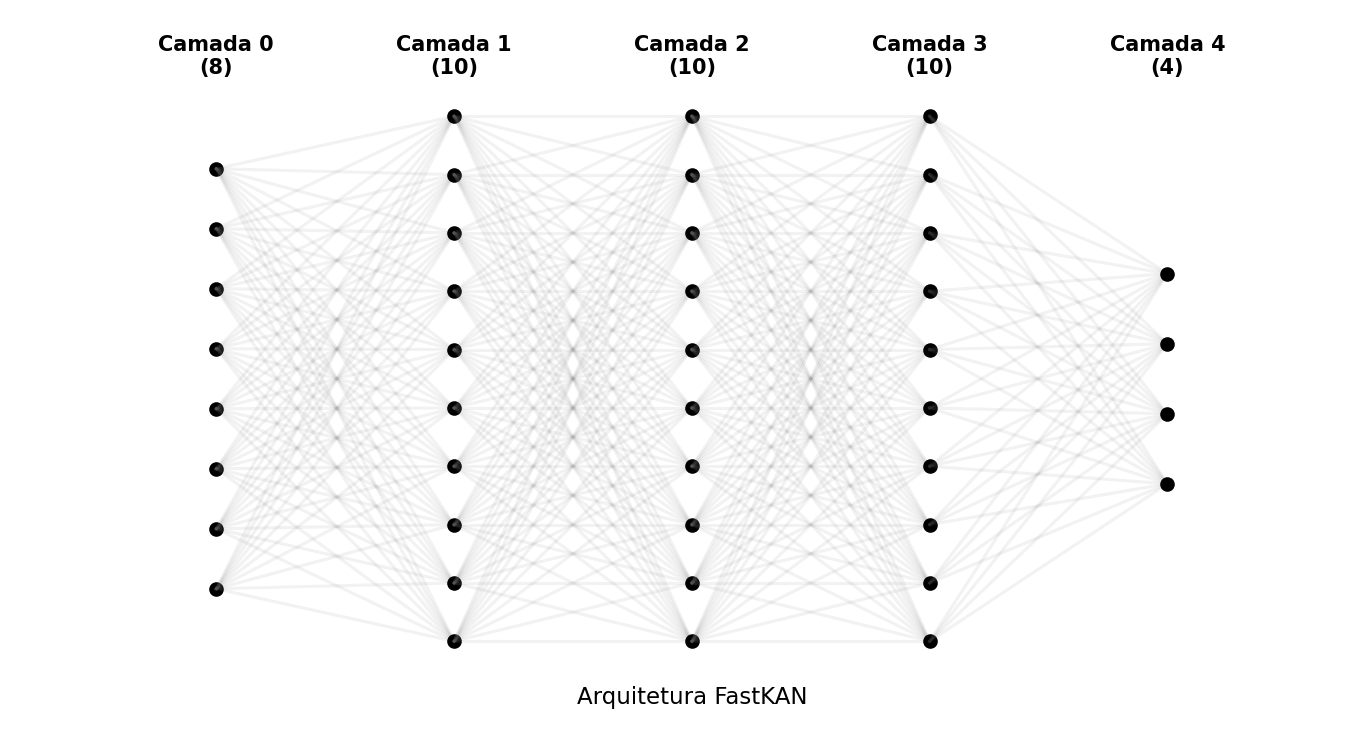

In [ ]:
plot_fastkan_arquitetura(input_dim, hidden_layers, output_dim, save_img)

## Gráficos

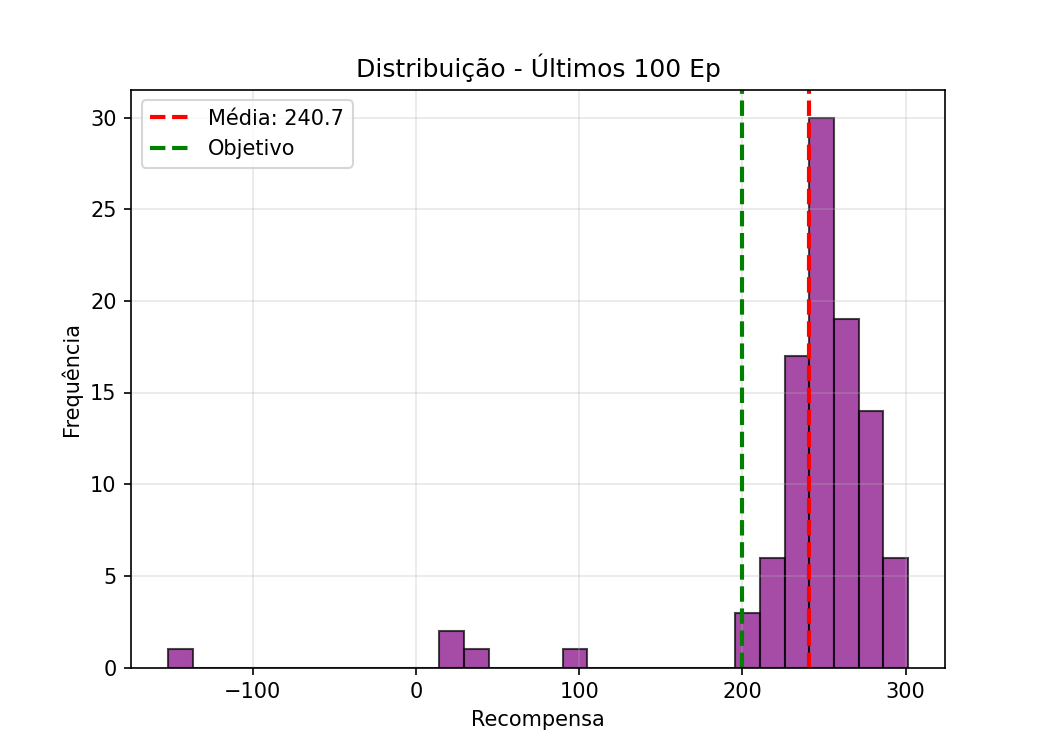

In [ ]:
plot_distribuicao_recompensa(rewards, save_img)

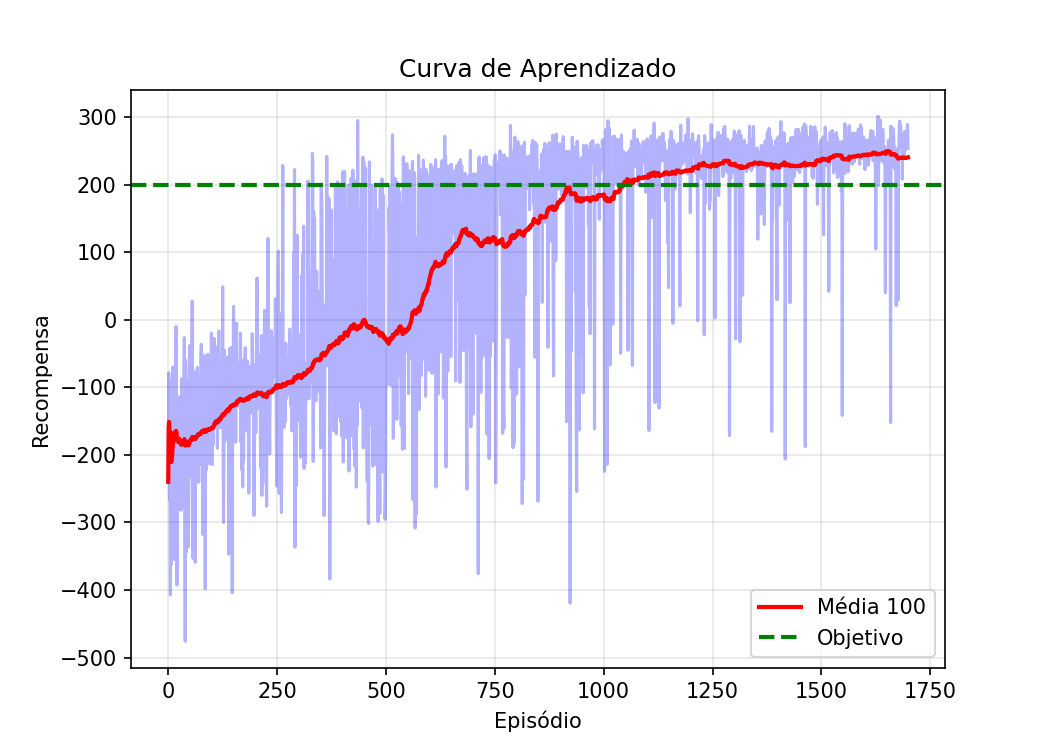

In [ ]:
plot_curva_aprendizado(rewards, save_img)

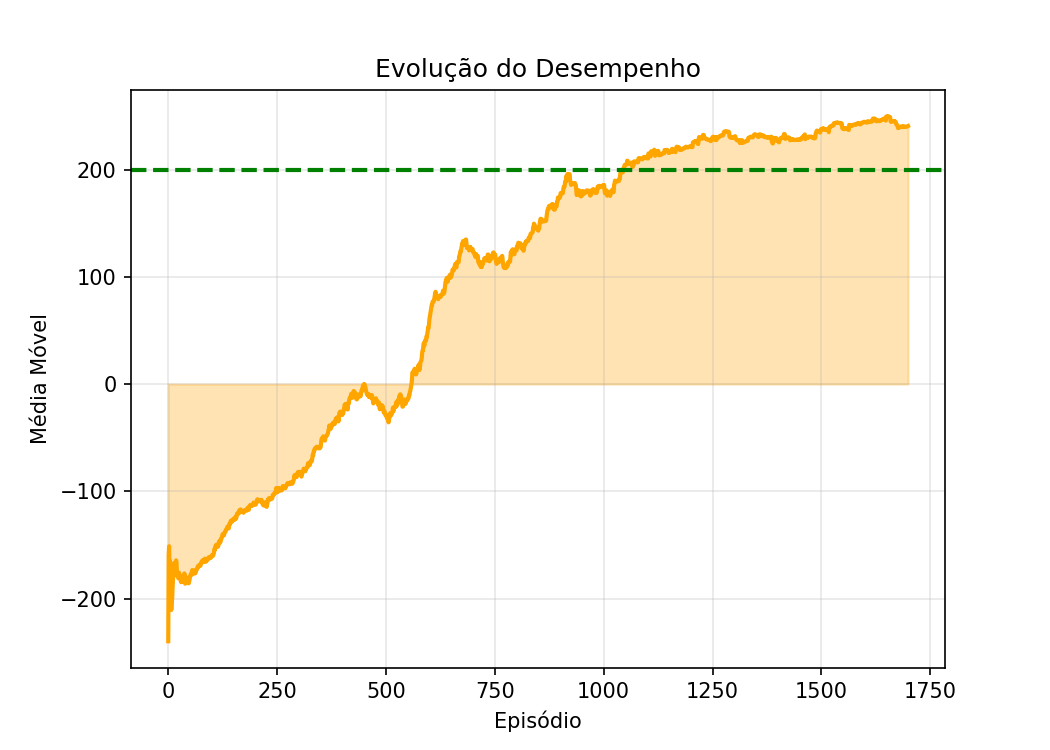

In [ ]:
plot_evolucao_desempenho(rewards, save_img)

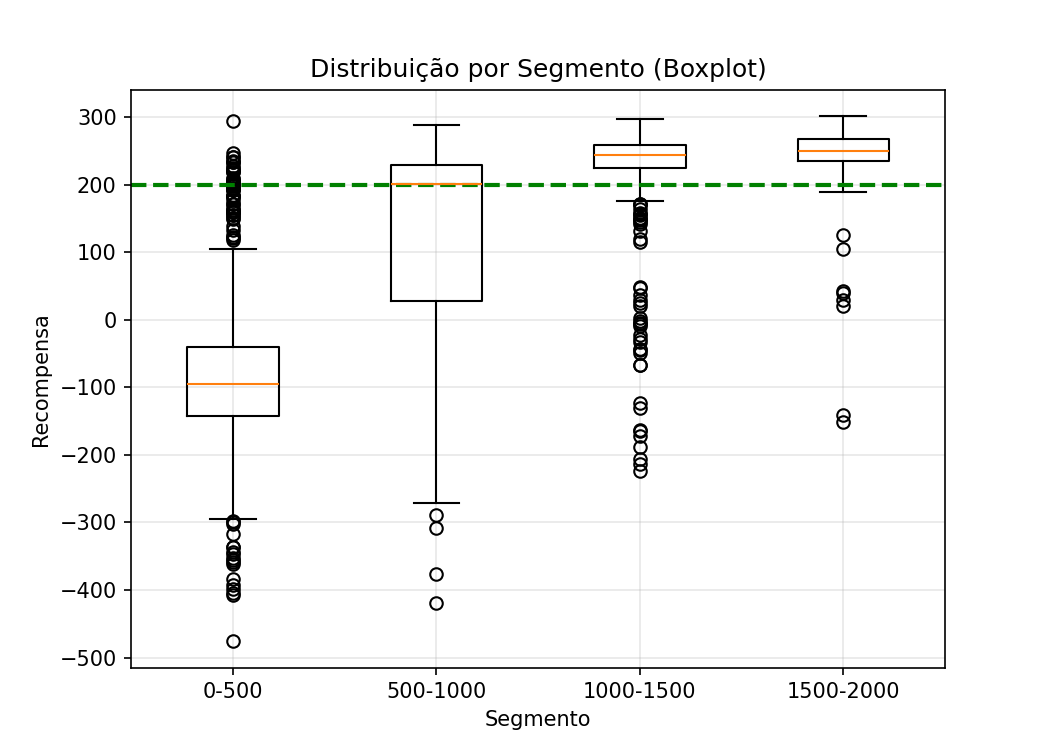

In [ ]:
plot_distribuicao_segmento(rewards, save_img)

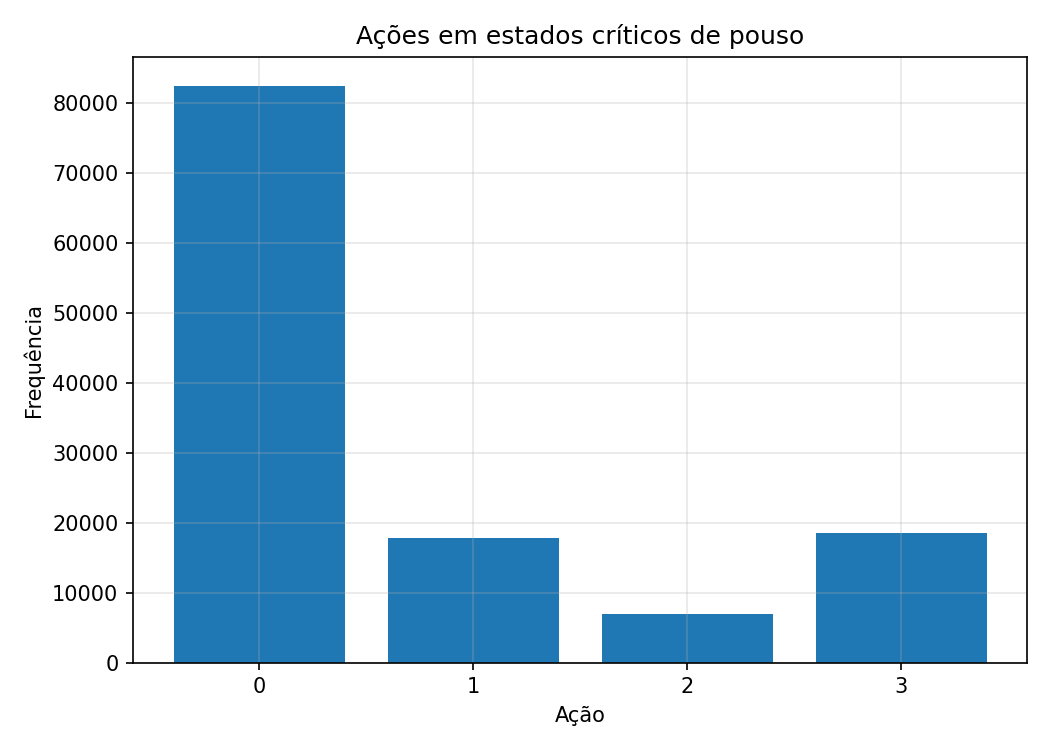

In [ ]:
plot_acoes_em_estado_critico(replay_buffer.buffer, save_img)

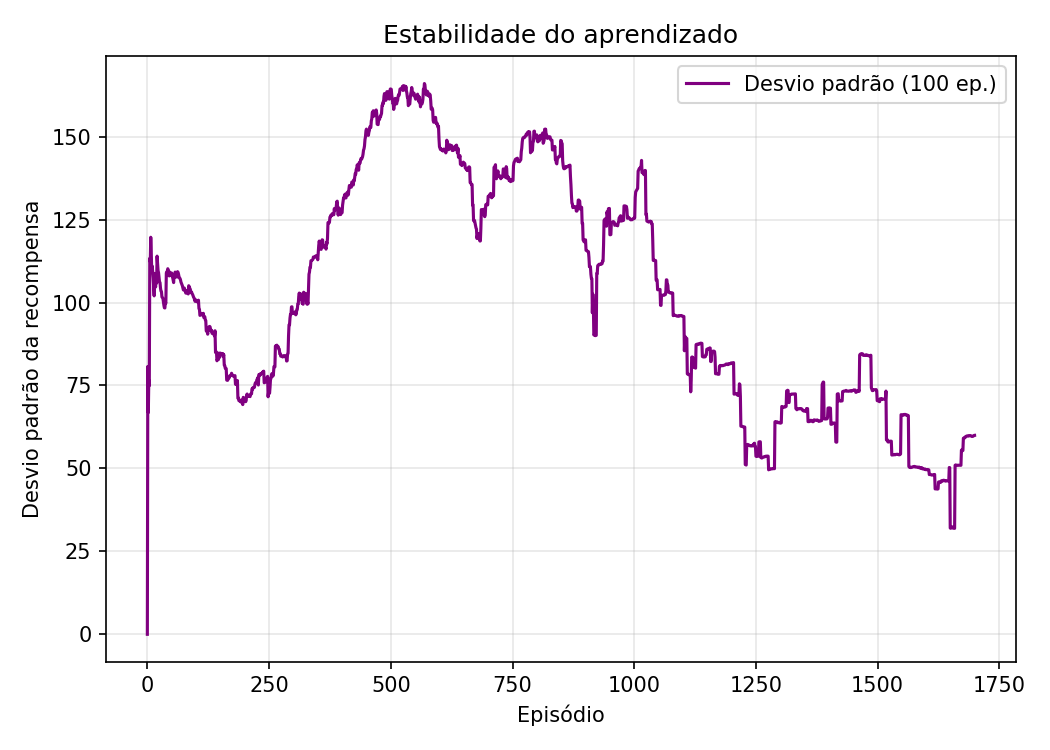

In [ ]:
plot_desvio_padrao_recompensa(rewards, save_img)

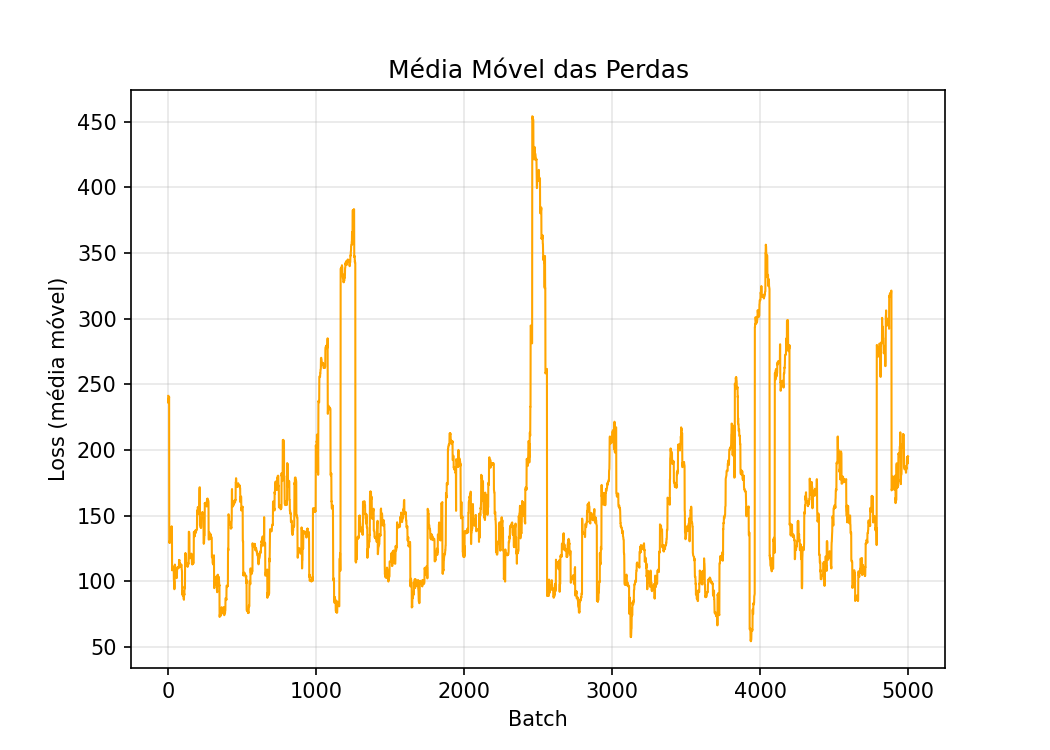

In [ ]:
plot_losses(agent.losses, save_img)

##Vídeos

In [ ]:
plot_video(env, layers, gamma, save_res, nome_agente)

Gravando vídeo do melhor agente...
Agente carregado de: resultados/fastkan_agente_56c16775af.pt
Vídeo gerado: videos/video-60006892a1-episode-0.mp4
Recompensa total: 248.71


In [ ]:
plot_video(env, layers, gamma, save_res, nome_agente)

Gravando vídeo do melhor agente...
Agente carregado de: resultados/fastkan_agente_56c16775af.pt
Vídeo gerado: videos/video-6602c1dd25-episode-0.mp4
Recompensa total: 266.47


In [ ]:
plot_video(env, layers, gamma, save_res, nome_agente)

Gravando vídeo do melhor agente...
Agente carregado de: resultados/fastkan_agente_56c16775af.pt
Vídeo gerado: videos/video-4156e02750-episode-0.mp4
Recompensa total: 140.57


In [ ]:
plot_video(env, layers, gamma, save_res, nome_agente)

Gravando vídeo do melhor agente...
Agente carregado de: resultados/fastkan_agente_56c16775af.pt
Vídeo gerado: videos/video-62fb514fb4-episode-0.mp4
Recompensa total: 274.58


In [ ]:
plot_video(env, layers, gamma, save_res, nome_agente)

Gravando vídeo do melhor agente...
Agente carregado de: resultados/fastkan_agente_56c16775af.pt
Vídeo gerado: videos/video-984d863650-episode-0.mp4
Recompensa total: 268.74


# 5. Execução (160)

In [ ]:
# Parâmetros de Execução Otimizados
seed = 160
set_seed(seed)
device = "cuda" if torch.cuda.is_available() else "cpu"
env_name = "LunarLander-v3"
num_episodes = 1700
capacity = 800000
batch_size = 16
n_step = 5
tau = 1.0
gamma = 0.99
lr = 1e-3
hidden_layers = [10, 10, 10]
warmup_episodes = 100
grid = 5

# Cria o ambiente
env = gym.make(env_name)
env.reset(seed=seed)
env.action_space.seed(seed)

input_dim = env.observation_space.shape[0]
output_dim = env.action_space.n
layers = [input_dim] + hidden_layers + [output_dim]

# Configuração da rede KAN
modelo = RLModelFastKAN(
    width=layers,
    grid=grid,
    ).to(device)

# Inicializa otimizador, agente e buffer
optimizer = optim.Adam(modelo.parameters(), lr)
agent = Agente(modelo, optimizer, env, gamma, save_res)
replay_buffer = BufferMultiStep(capacity, n_step, gamma)

# Executa o treinamento
timer = Timer()

nome_agente, rewards, avg_rewards, best_reward, best_episode = run_experiment(
    env,
    agent,
    replay_buffer,
    num_episodes,
    batch_size,
    warmup_episodes,
    save_res,
    render=False
)
timer.stop()


(19:48:25) Iniciou execução...
Rodando na cuda:0
Ep    1/1700 [WARMUP] | R: -111.14 | Media10: -111.14 | Media100: -111.14 | eps: 0.995 | Buf:     71
Ep    2/1700 [WARMUP] | R: -196.36 | Media10: -153.75 | Media100: -153.75 | eps: 0.990 | Buf:    145
Ep    3/1700 [WARMUP] | R: -131.28 | Media10: -146.26 | Media100: -146.26 | eps: 0.985 | Buf:    212
Ep    4/1700 [WARMUP] | R:    1.10 | Media10: -109.42 | Media100: -109.42 | eps: 0.980 | Buf:    352
Ep    5/1700 [WARMUP] | R: -134.51 | Media10: -114.44 | Media100: -114.44 | eps: 0.975 | Buf:    449
Ep    6/1700 [WARMUP] | R:   -9.12 | Media10:  -96.88 | Media100:  -96.88 | eps: 0.970 | Buf:    559
Ep    7/1700 [WARMUP] | R: -399.48 | Media10: -140.11 | Media100: -140.11 | eps: 0.966 | Buf:    679
Ep    8/1700 [WARMUP] | R:  -43.19 | Media10: -128.00 | Media100: -128.00 | eps: 0.961 | Buf:    759
Ep    9/1700 [WARMUP] | R: -219.87 | Media10: -138.20 | Media100: -138.20 | eps: 0.956 | Buf:    865
Ep   10/1700 [WARMUP] | R: -110.86 | Media

In [ ]:
caminho_arquivo = os.path.join(save_res, nome_agente)
print(f'{caminho_arquivo}')
# Verifica se o arquivo existe antes de tentar baixar
if os.path.exists(caminho_arquivo):
    files.download(caminho_arquivo)
else:
    print("Erro: O arquivo não foi encontrado na pasta /resultados.")

#6. Resultados (160)

In [ ]:
print('seed', seed)
print('device', device)
print('env_name', env_name)
print('num_episodes', num_episodes)
print('capacity', capacity)
print('batch_size', batch_size)
print('n_step', n_step)
print('tau', tau)
print('gamma', gamma)
print('lr', lr)
print('hidden_layers', hidden_layers)
print('warmup_episodes', warmup_episodes)
print('grid', grid)

seed 160
device cuda
env_name LunarLander-v3
num_episodes 1700
capacity 800000
batch_size 16
n_step 5
tau 1.0
gamma 0.99
lr 0.001
hidden_layers [10, 10, 10]
warmup_episodes 100
grid 5


## Desempenho

In [ ]:
plot_desempenho(rewards, best_reward, best_episode)

Desempenho:
 Melhor resultado: 307.12 (episódio 1640)
 Melhor média (100 ep): 257.24 (episódio 1682)
 Média últimos (100 ep): 248.19 ± 72.00
 Taxa de sucesso (>200): 94.0% (94/100)
Conclusão:
 SUCESSO! Agente RESOLVEU o ambiente!


In [ ]:
with torch.cuda.device(0):
  macs, params = get_model_complexity_info(
      modelo,
      (input_dim,),
      as_strings=True,
      print_per_layer_stat=True,
      verbose=True,
  )
print("FLOPs (MACs):", macs)
print("Parâmetros:", params)

RLModelFastKAN(
  430, 21.182% Params, 392.0 Mac, 100.000% MACs, 
  (kan_model): FastKAN(
    430, 21.182% Params, 392.0 Mac, 100.000% MACs, 
    (layers): ModuleList(
      (0): FastKANLayer(
        106, 5.222% Params, 98.0 Mac, 25.000% MACs, 
        (layernorm): LayerNorm(16, 0.788% Params, 8.0 Mac, 2.041% MACs, (8,), eps=1e-05, elementwise_affine=True)
        (rbf): RadialBasisFunction(0, 0.000% Params, 0.0 Mac, 0.000% MACs, )
        (spline_linear): SplineLinear(0, 0.000% Params, 0.0 Mac, 0.000% MACs, in_features=40, out_features=10, bias=False)
        (base_linear): Linear(90, 4.433% Params, 90.0 Mac, 22.959% MACs, in_features=8, out_features=10, bias=True)
      )
      (1-2): 2 x FastKANLayer(
        130, 6.404% Params, 120.0 Mac, 30.612% MACs, 
        (layernorm): LayerNorm(20, 0.985% Params, 10.0 Mac, 2.551% MACs, (10,), eps=1e-05, elementwise_affine=True)
        (rbf): RadialBasisFunction(0, 0.000% Params, 0.0 Mac, 0.000% MACs, )
        (spline_linear): SplineLinear(

## Arquitetura da Rede

In [ ]:
print(modelo)

RLModelFastKAN(
  (kan_model): FastKAN(
    (layers): ModuleList(
      (0): FastKANLayer(
        (layernorm): LayerNorm((8,), eps=1e-05, elementwise_affine=True)
        (rbf): RadialBasisFunction()
        (spline_linear): SplineLinear(in_features=40, out_features=10, bias=False)
        (base_linear): Linear(in_features=8, out_features=10, bias=True)
      )
      (1-2): 2 x FastKANLayer(
        (layernorm): LayerNorm((10,), eps=1e-05, elementwise_affine=True)
        (rbf): RadialBasisFunction()
        (spline_linear): SplineLinear(in_features=50, out_features=10, bias=False)
        (base_linear): Linear(in_features=10, out_features=10, bias=True)
      )
      (3): FastKANLayer(
        (layernorm): LayerNorm((10,), eps=1e-05, elementwise_affine=True)
        (rbf): RadialBasisFunction()
        (spline_linear): SplineLinear(in_features=50, out_features=4, bias=False)
        (base_linear): Linear(in_features=10, out_features=4, bias=True)
      )
    )
  )
)


In [ ]:
summary(modelo, input_size=(1, input_dim))

Layer (type:depth-idx)                             Output Shape              Param #
RLModelFastKAN                                     [1, 4]                    --
├─FastKAN: 1-1                                     [1, 4]                    --
│    └─ModuleList: 2-1                             --                        --
│    │    └─FastKANLayer: 3-1                      [1, 10]                   511
│    │    └─FastKANLayer: 3-2                      [1, 10]                   635
│    │    └─FastKANLayer: 3-3                      [1, 10]                   635
│    │    └─FastKANLayer: 3-4                      [1, 4]                    269
Total params: 2,050
Trainable params: 2,030
Non-trainable params: 20
Total mult-adds (Units.MEGABYTES): 0.00
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.01
Estimated Total Size (MB): 0.01

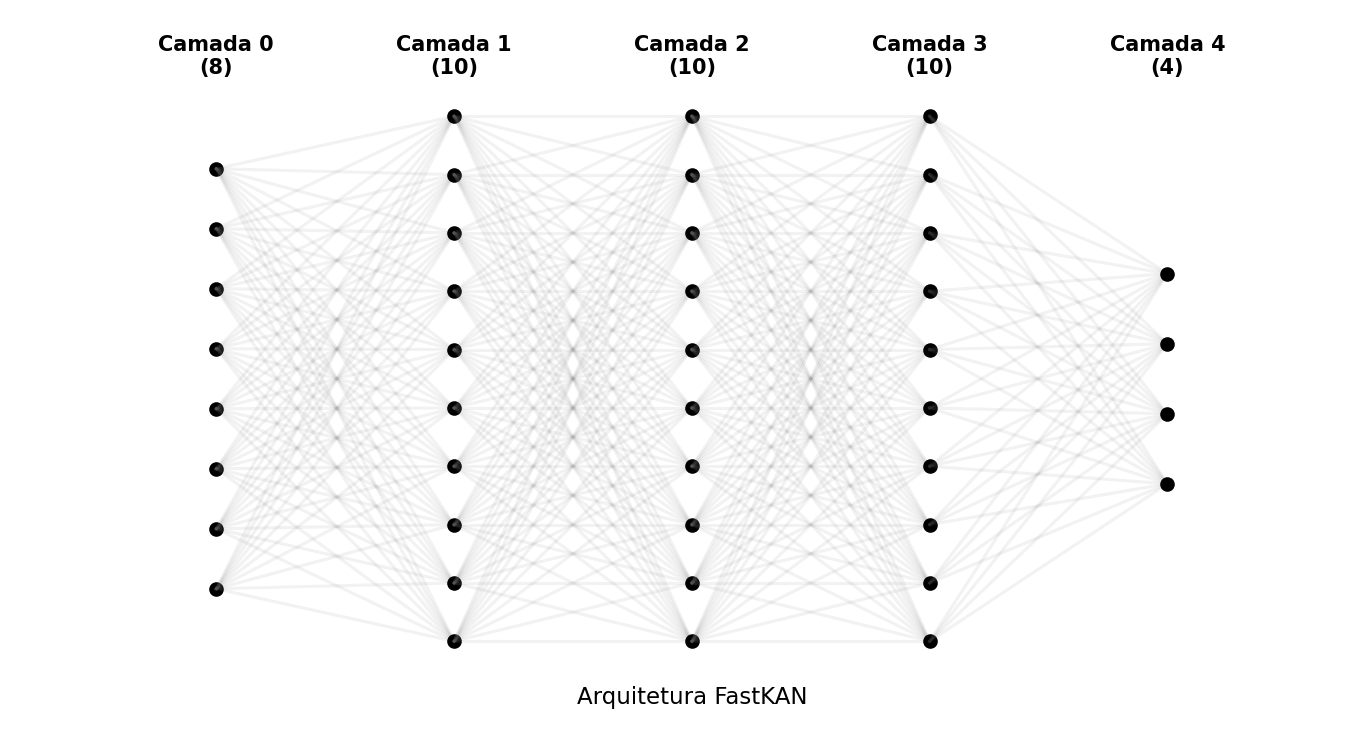

In [ ]:
plot_fastkan_arquitetura(input_dim, hidden_layers, output_dim, save_img)

## Gráficos

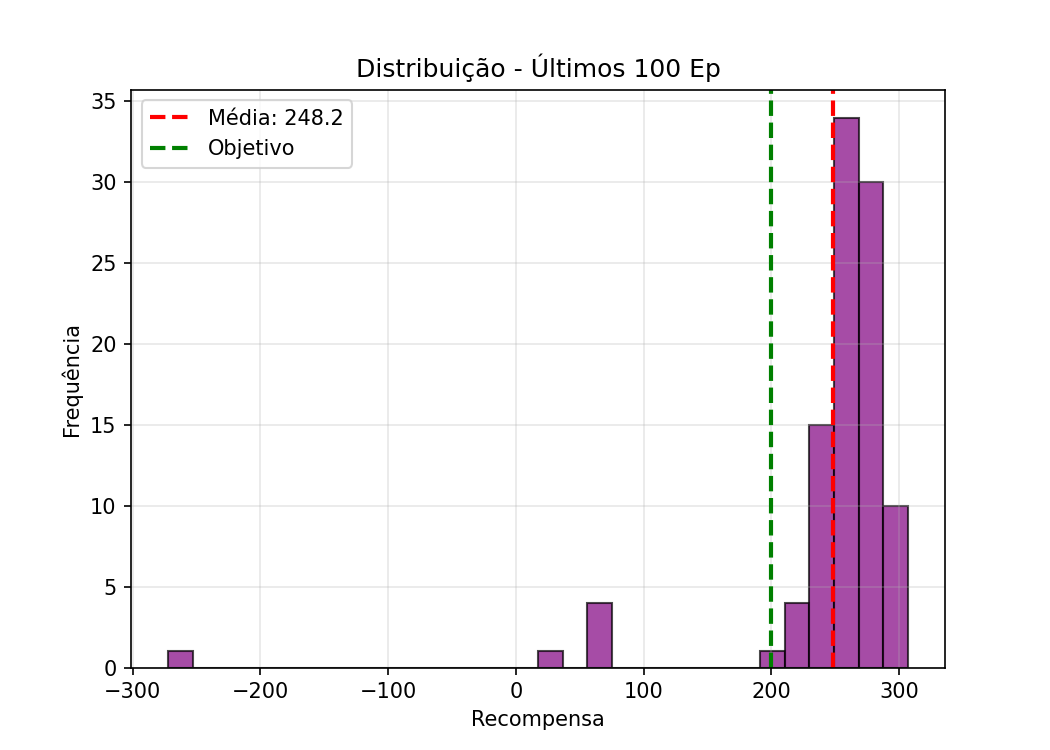

In [ ]:
plot_distribuicao_recompensa(rewards, save_img)

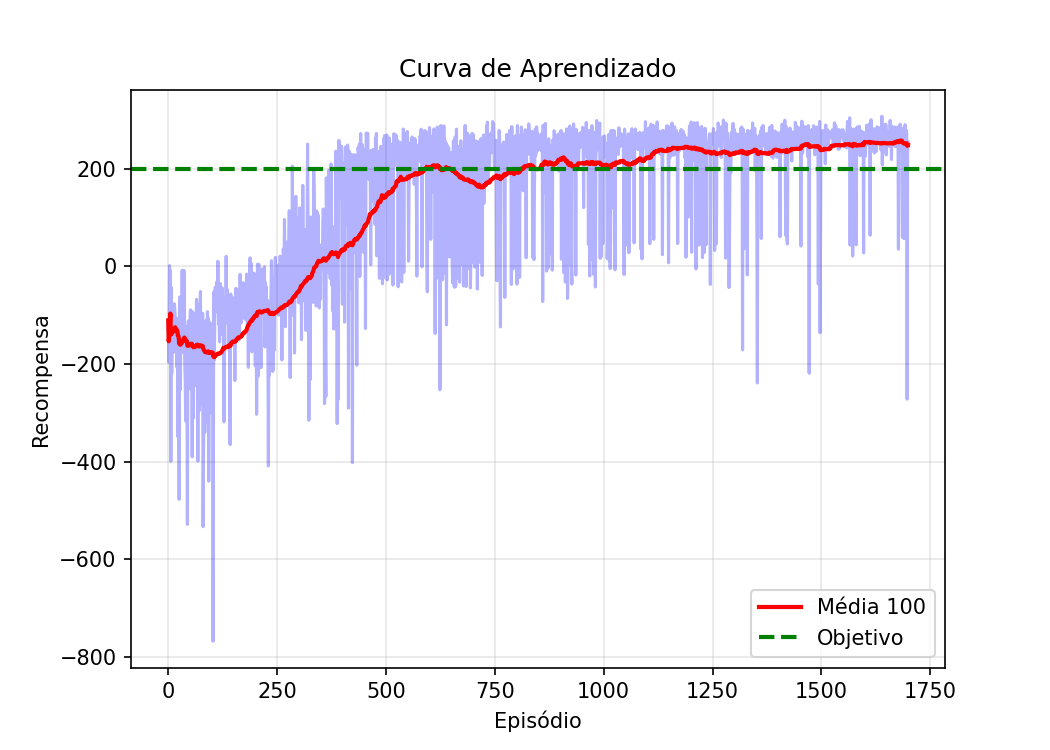

In [ ]:
plot_curva_aprendizado(rewards, save_img)

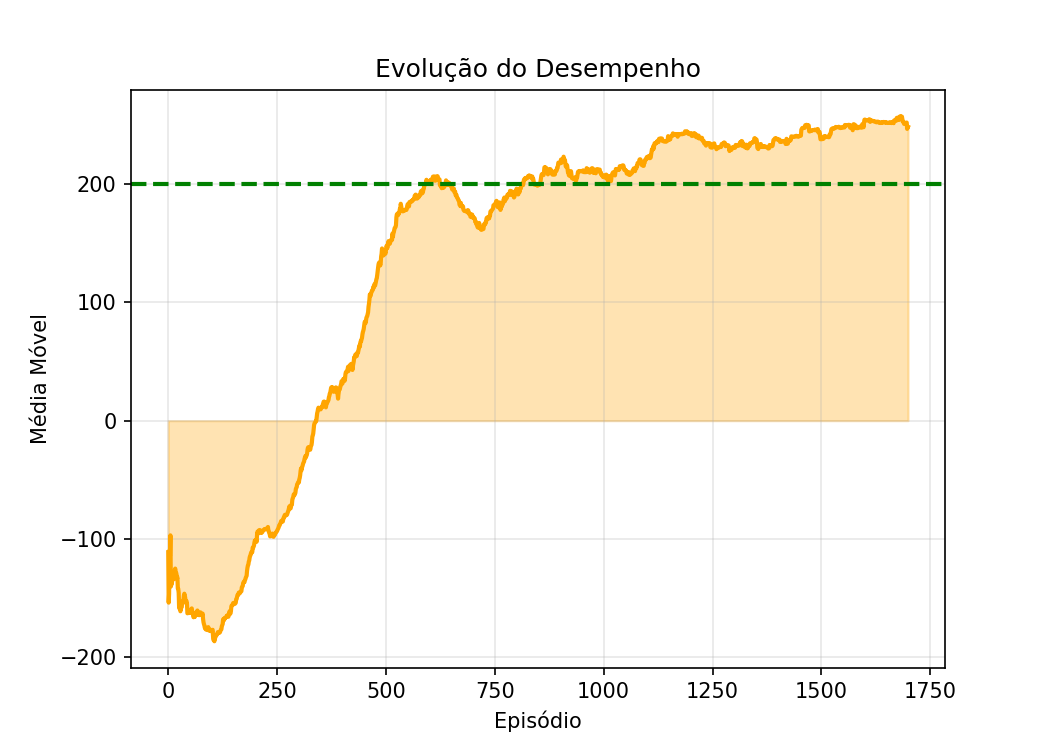

In [ ]:
plot_evolucao_desempenho(rewards, save_img)

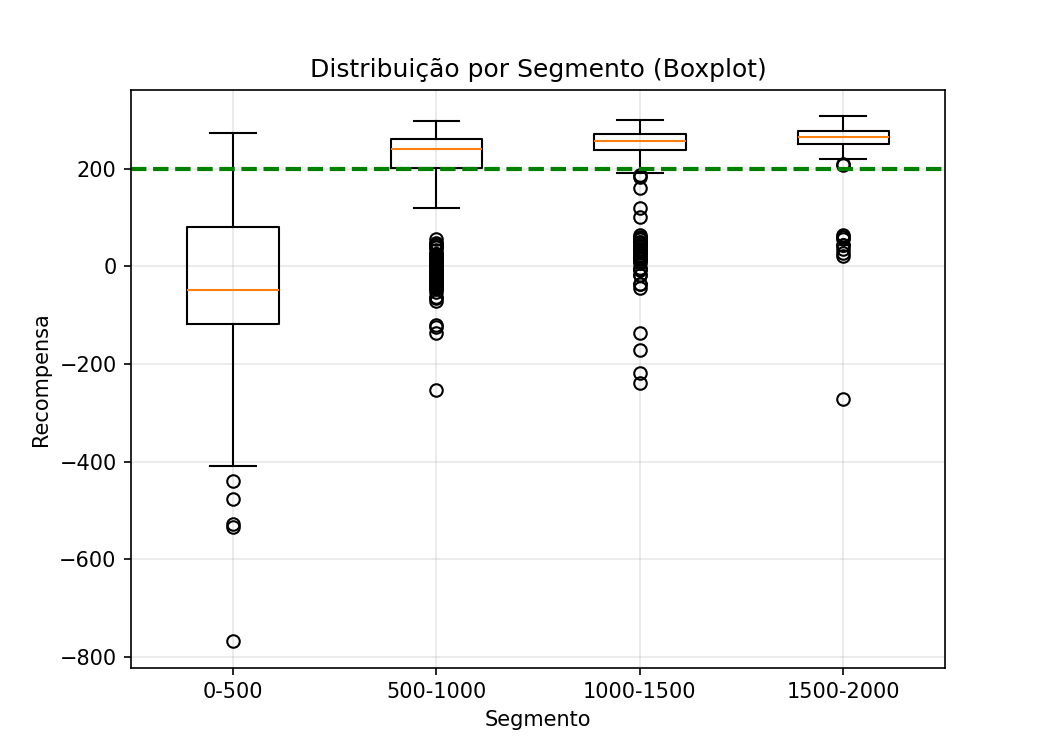

In [ ]:
plot_distribuicao_segmento(rewards, save_img)

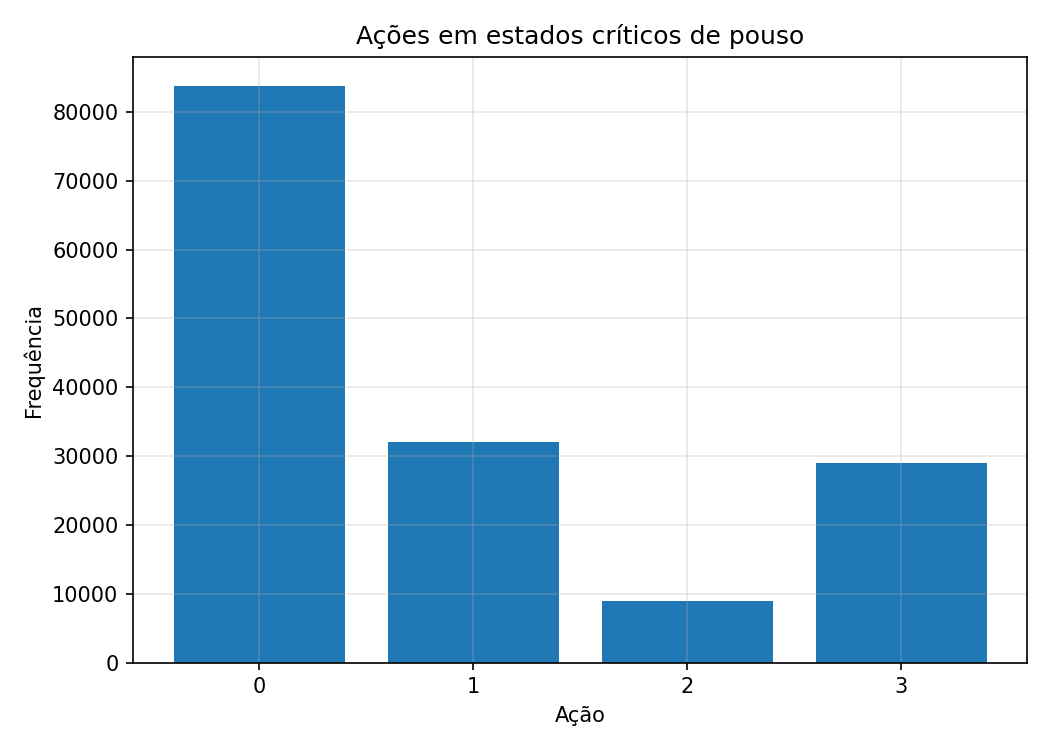

In [ ]:
plot_acoes_em_estado_critico(replay_buffer.buffer, save_img)

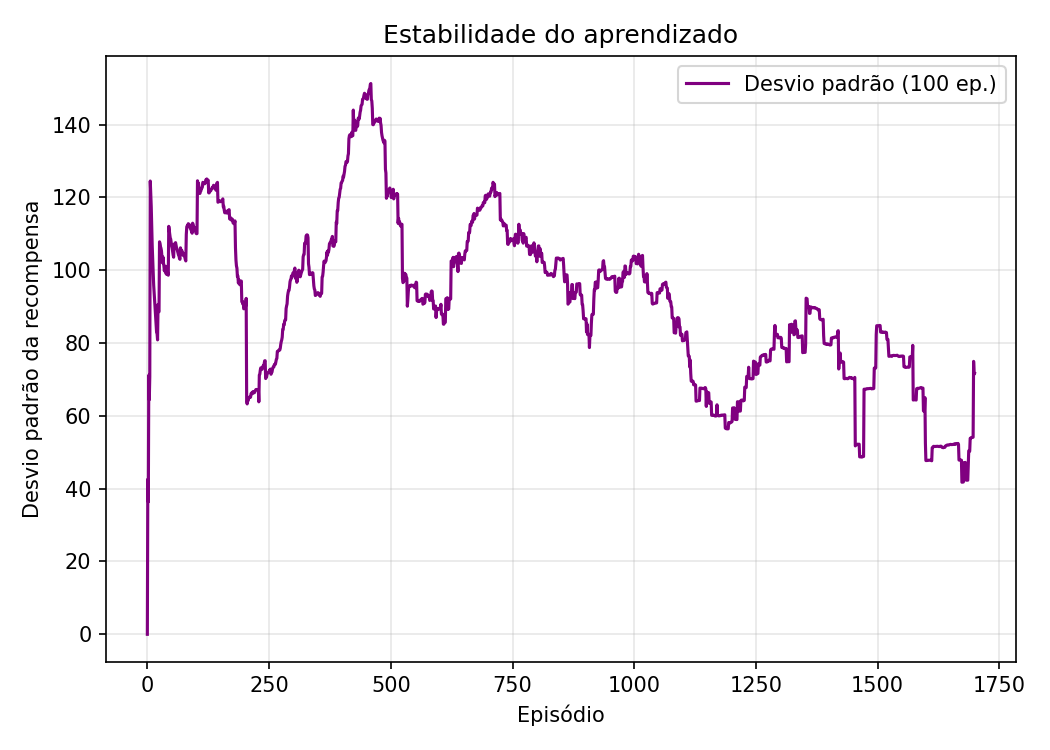

In [ ]:
plot_desvio_padrao_recompensa(rewards, save_img)

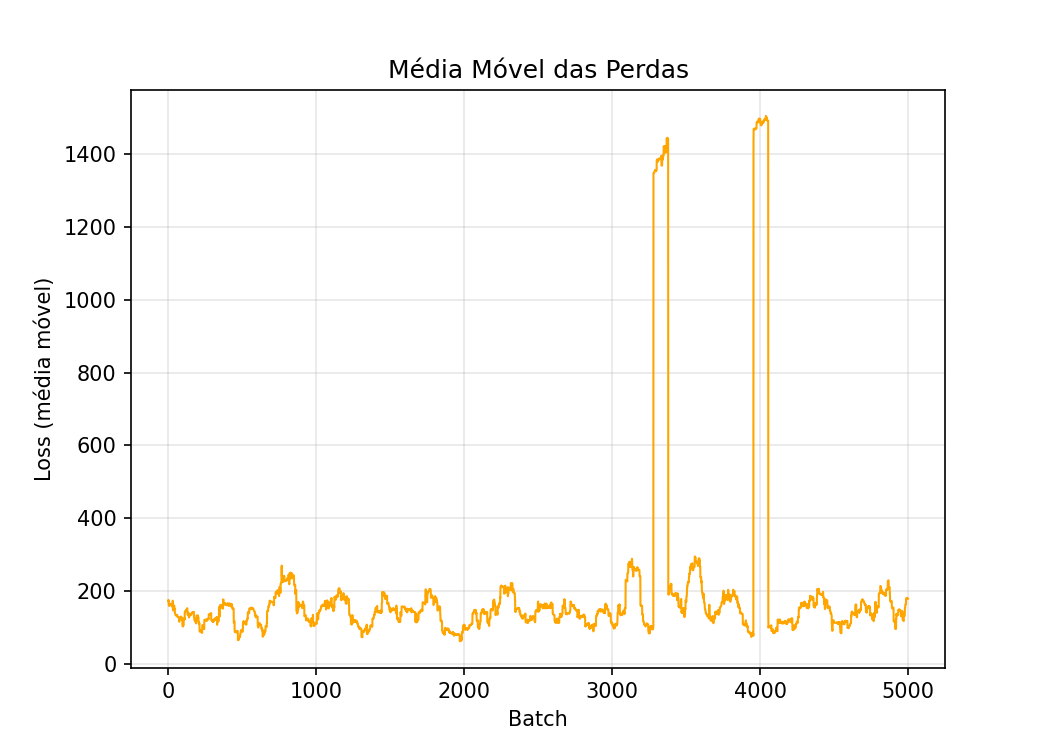

In [ ]:
plot_losses(agent.losses, save_img)

##Vídeos

In [ ]:
plot_video(env, layers, gamma, save_res, nome_agente)

Gravando vídeo do melhor agente...
Agente carregado de: resultados/fastkan_agente_5946ad06f3.pt
Vídeo gerado: videos/video-20d156c21d-episode-0.mp4
Recompensa total: 244.85


In [ ]:
plot_video(env, layers, gamma, save_res, nome_agente)

Gravando vídeo do melhor agente...
Agente carregado de: resultados/fastkan_agente_5946ad06f3.pt
Vídeo gerado: videos/video-476aed48e7-episode-0.mp4
Recompensa total: 24.97


In [ ]:
plot_video(env, layers, gamma, save_res, nome_agente)

Gravando vídeo do melhor agente...
Agente carregado de: resultados/fastkan_agente_5946ad06f3.pt
Vídeo gerado: videos/video-a11f8d6c55-episode-0.mp4
Recompensa total: 235.63


In [ ]:
plot_video(env, layers, gamma, save_res, nome_agente)

Gravando vídeo do melhor agente...
Agente carregado de: resultados/fastkan_agente_5946ad06f3.pt
Vídeo gerado: videos/video-5a4a2b6eba-episode-0.mp4
Recompensa total: 250.52


In [ ]:
plot_video(env, layers, gamma, save_res, nome_agente)

Gravando vídeo do melhor agente...
Agente carregado de: resultados/fastkan_agente_5946ad06f3.pt
Vídeo gerado: videos/video-334f4adecc-episode-0.mp4
Recompensa total: 261.45


# 5. Execução (198)

In [ ]:
# Parâmetros de Execução Otimizados
seed = 198
set_seed(seed)
device = "cuda" if torch.cuda.is_available() else "cpu"
env_name = "LunarLander-v3"
num_episodes = 1700
capacity = 800000
batch_size = 16
n_step = 5
tau = 1.0
gamma = 0.99
lr = 1e-3
hidden_layers = [10, 10, 10]
warmup_episodes = 100
grid = 5 # número de divisões por dimensão FastKAN

# Cria o ambiente
env = gym.make(env_name)
env.reset(seed=seed)
env.action_space.seed(seed)

input_dim = env.observation_space.shape[0]
output_dim = env.action_space.n
layers = [input_dim] + hidden_layers + [output_dim]

# Configuração da rede KAN
modelo = RLModelFastKAN(
    width=layers,
    grid=grid,
    ).to(device)

# Inicializa otimizador, agente e buffer
optimizer = optim.Adam(modelo.parameters(), lr)
agent = Agente(modelo, optimizer, env, gamma, save_res)
replay_buffer = BufferMultiStep(capacity, n_step, gamma)

# Executa o treinamento
timer = Timer()

nome_agente, rewards, avg_rewards, best_reward, best_episode = run_experiment(
    env,
    agent,
    replay_buffer,
    num_episodes,
    batch_size,
    warmup_episodes,
    save_res,
    render=False
)
timer.stop()


(21:50:11) Iniciou execução...
Rodando na cuda:0
Ep    1/1700 [WARMUP] | R: -124.92 | Media10: -124.92 | Media100: -124.92 | eps: 0.995 | Buf:     55
Ep    2/1700 [WARMUP] | R: -351.82 | Media10: -238.37 | Media100: -238.37 | eps: 0.990 | Buf:    179
Ep    3/1700 [WARMUP] | R: -137.47 | Media10: -204.73 | Media100: -204.73 | eps: 0.985 | Buf:    284
Ep    4/1700 [WARMUP] | R: -264.95 | Media10: -219.79 | Media100: -219.79 | eps: 0.980 | Buf:    388
Ep    5/1700 [WARMUP] | R: -242.41 | Media10: -224.31 | Media100: -224.31 | eps: 0.975 | Buf:    463
Ep    6/1700 [WARMUP] | R: -102.65 | Media10: -204.04 | Media100: -204.04 | eps: 0.970 | Buf:    570
Ep    7/1700 [WARMUP] | R: -299.01 | Media10: -217.60 | Media100: -217.60 | eps: 0.966 | Buf:    649
Ep    8/1700 [WARMUP] | R: -120.24 | Media10: -205.43 | Media100: -205.43 | eps: 0.961 | Buf:    760
Ep    9/1700 [WARMUP] | R: -260.84 | Media10: -211.59 | Media100: -211.59 | eps: 0.956 | Buf:    855
Ep   10/1700 [WARMUP] | R: -280.49 | Media

In [ ]:
caminho_arquivo = os.path.join(save_res, nome_agente)
print(f'{caminho_arquivo}')
# Verifica se o arquivo existe antes de tentar baixar
if os.path.exists(caminho_arquivo):
    files.download(caminho_arquivo)
else:
    print("Erro: O arquivo não foi encontrado na pasta /resultados.")

#6. Resultados (198)

In [ ]:
print('seed', seed)
print('device', device)
print('env_name', env_name)
print('num_episodes', num_episodes)
print('capacity', capacity)
print('batch_size', batch_size)
print('n_step', n_step)
print('tau', tau)
print('gamma', gamma)
print('lr', lr)
print('hidden_layers', hidden_layers)
print('warmup_episodes', warmup_episodes)
print('grid', grid)

seed 198
device cuda
env_name LunarLander-v3
num_episodes 1700
capacity 800000
batch_size 16
n_step 5
tau 1.0
gamma 0.99
lr 0.001
hidden_layers [10, 10, 10]
warmup_episodes 100
grid 5


## Desempenho

In [ ]:
plot_desempenho(rewards, best_reward, best_episode)

Desempenho:
 Melhor resultado: 301.59 (episódio 1019)
 Melhor média (100 ep): 251.29 (episódio 1425)
 Média últimos (100 ep): 226.78 ± 102.65
 Taxa de sucesso (>200): 89.0% (89/100)
Conclusão:
 SUCESSO! Agente RESOLVEU o ambiente!


In [ ]:
with torch.cuda.device(0):
  macs, params = get_model_complexity_info(
      modelo,
      (input_dim,),
      as_strings=True,
      print_per_layer_stat=True,
      verbose=True,
  )
print("FLOPs (MACs):", macs)
print("Parâmetros:", params)

RLModelFastKAN(
  430, 21.182% Params, 392.0 Mac, 100.000% MACs, 
  (kan_model): FastKAN(
    430, 21.182% Params, 392.0 Mac, 100.000% MACs, 
    (layers): ModuleList(
      (0): FastKANLayer(
        106, 5.222% Params, 98.0 Mac, 25.000% MACs, 
        (layernorm): LayerNorm(16, 0.788% Params, 8.0 Mac, 2.041% MACs, (8,), eps=1e-05, elementwise_affine=True)
        (rbf): RadialBasisFunction(0, 0.000% Params, 0.0 Mac, 0.000% MACs, )
        (spline_linear): SplineLinear(0, 0.000% Params, 0.0 Mac, 0.000% MACs, in_features=40, out_features=10, bias=False)
        (base_linear): Linear(90, 4.433% Params, 90.0 Mac, 22.959% MACs, in_features=8, out_features=10, bias=True)
      )
      (1-2): 2 x FastKANLayer(
        130, 6.404% Params, 120.0 Mac, 30.612% MACs, 
        (layernorm): LayerNorm(20, 0.985% Params, 10.0 Mac, 2.551% MACs, (10,), eps=1e-05, elementwise_affine=True)
        (rbf): RadialBasisFunction(0, 0.000% Params, 0.0 Mac, 0.000% MACs, )
        (spline_linear): SplineLinear(

## Arquitetura da Rede

In [ ]:
print(modelo)

RLModelFastKAN(
  (kan_model): FastKAN(
    (layers): ModuleList(
      (0): FastKANLayer(
        (layernorm): LayerNorm((8,), eps=1e-05, elementwise_affine=True)
        (rbf): RadialBasisFunction()
        (spline_linear): SplineLinear(in_features=40, out_features=10, bias=False)
        (base_linear): Linear(in_features=8, out_features=10, bias=True)
      )
      (1-2): 2 x FastKANLayer(
        (layernorm): LayerNorm((10,), eps=1e-05, elementwise_affine=True)
        (rbf): RadialBasisFunction()
        (spline_linear): SplineLinear(in_features=50, out_features=10, bias=False)
        (base_linear): Linear(in_features=10, out_features=10, bias=True)
      )
      (3): FastKANLayer(
        (layernorm): LayerNorm((10,), eps=1e-05, elementwise_affine=True)
        (rbf): RadialBasisFunction()
        (spline_linear): SplineLinear(in_features=50, out_features=4, bias=False)
        (base_linear): Linear(in_features=10, out_features=4, bias=True)
      )
    )
  )
)


In [ ]:
summary(modelo, input_size=(1, input_dim))

Layer (type:depth-idx)                             Output Shape              Param #
RLModelFastKAN                                     [1, 4]                    --
├─FastKAN: 1-1                                     [1, 4]                    --
│    └─ModuleList: 2-1                             --                        --
│    │    └─FastKANLayer: 3-1                      [1, 10]                   511
│    │    └─FastKANLayer: 3-2                      [1, 10]                   635
│    │    └─FastKANLayer: 3-3                      [1, 10]                   635
│    │    └─FastKANLayer: 3-4                      [1, 4]                    269
Total params: 2,050
Trainable params: 2,030
Non-trainable params: 20
Total mult-adds (Units.MEGABYTES): 0.00
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.01
Estimated Total Size (MB): 0.01

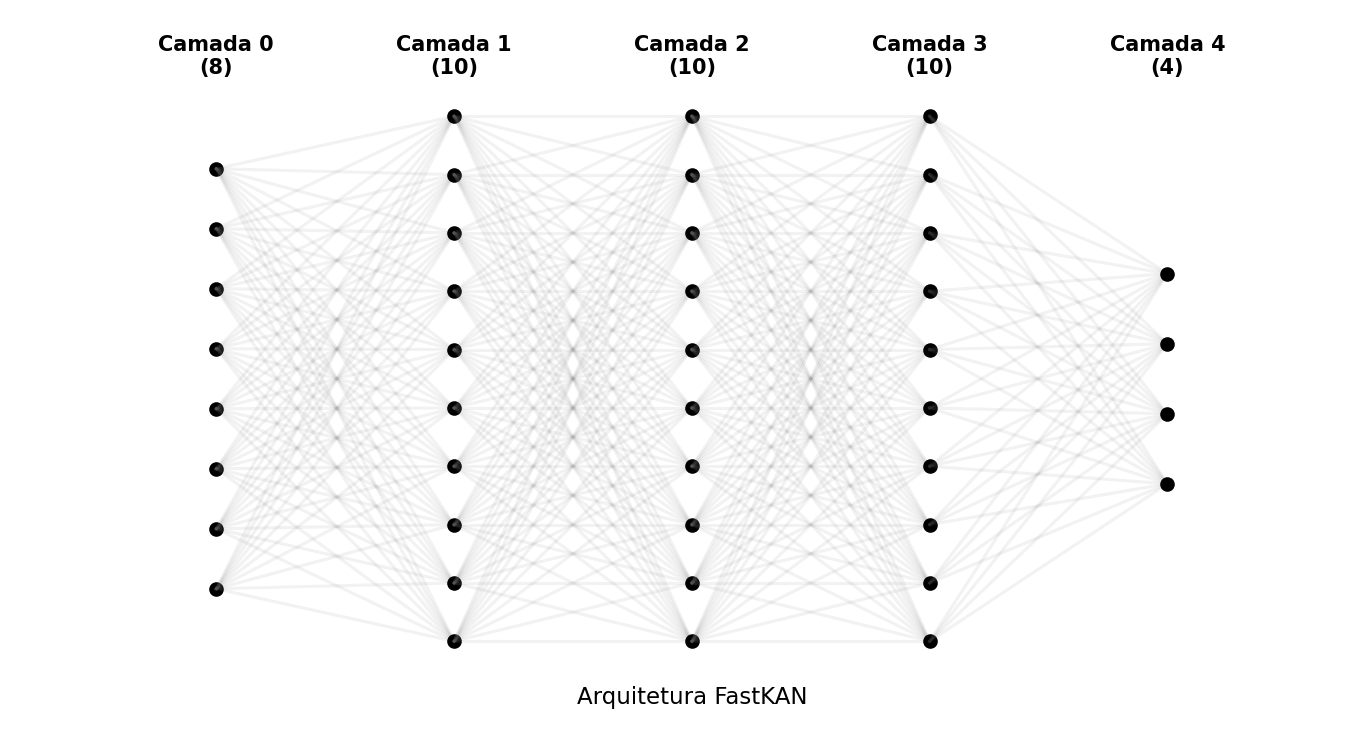

In [ ]:
plot_fastkan_arquitetura(input_dim, hidden_layers, output_dim, save_img)

## Gráficos

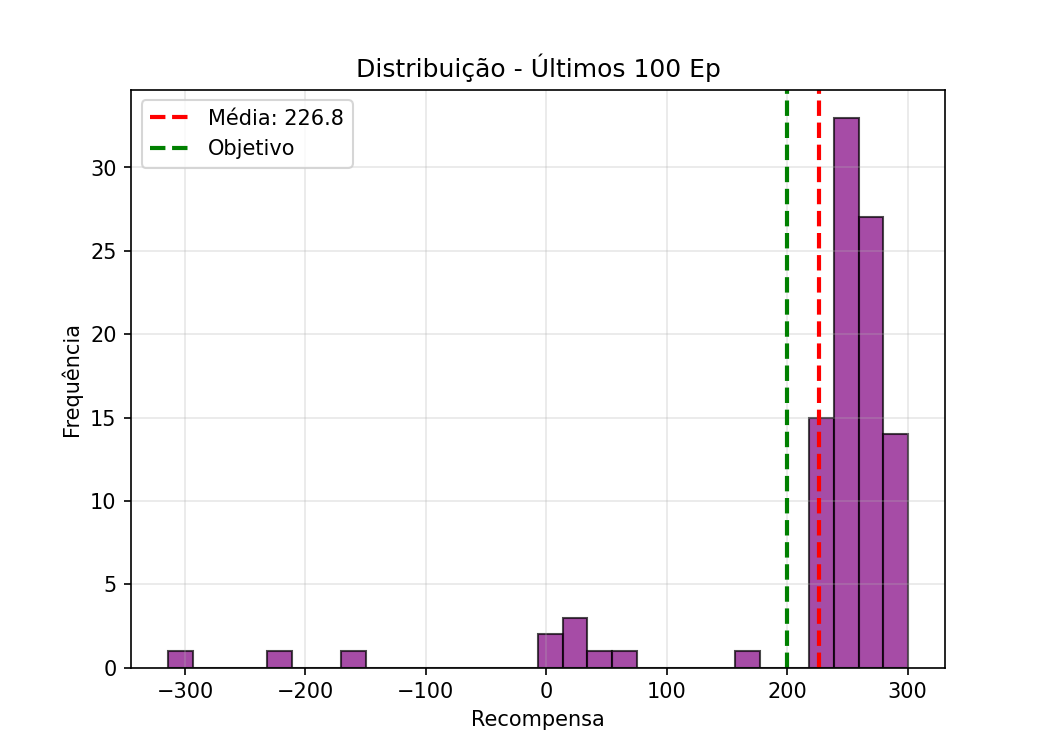

In [ ]:
plot_distribuicao_recompensa(rewards, save_img)

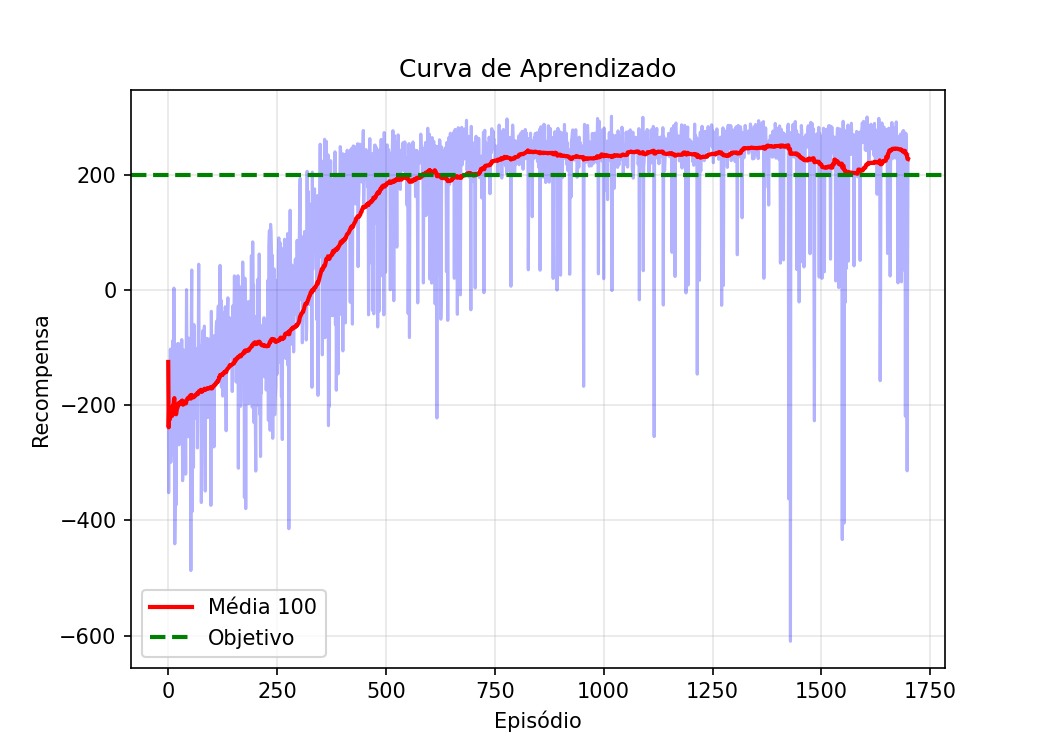

In [ ]:
plot_curva_aprendizado(rewards, save_img)

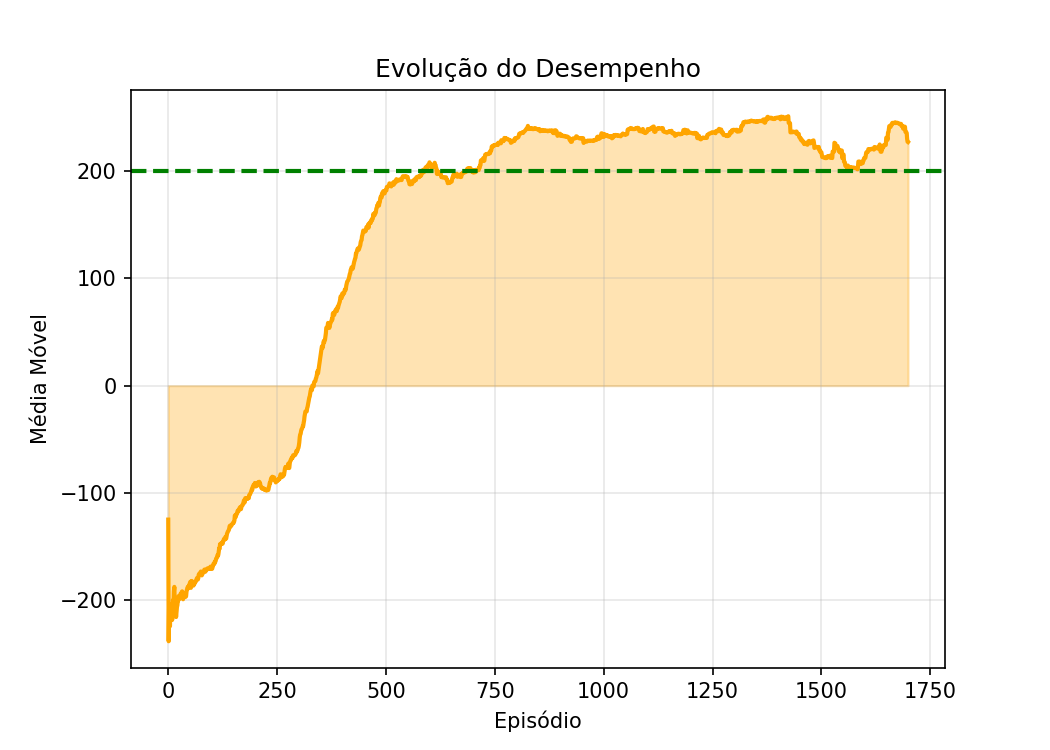

In [ ]:
plot_evolucao_desempenho(rewards, save_img)

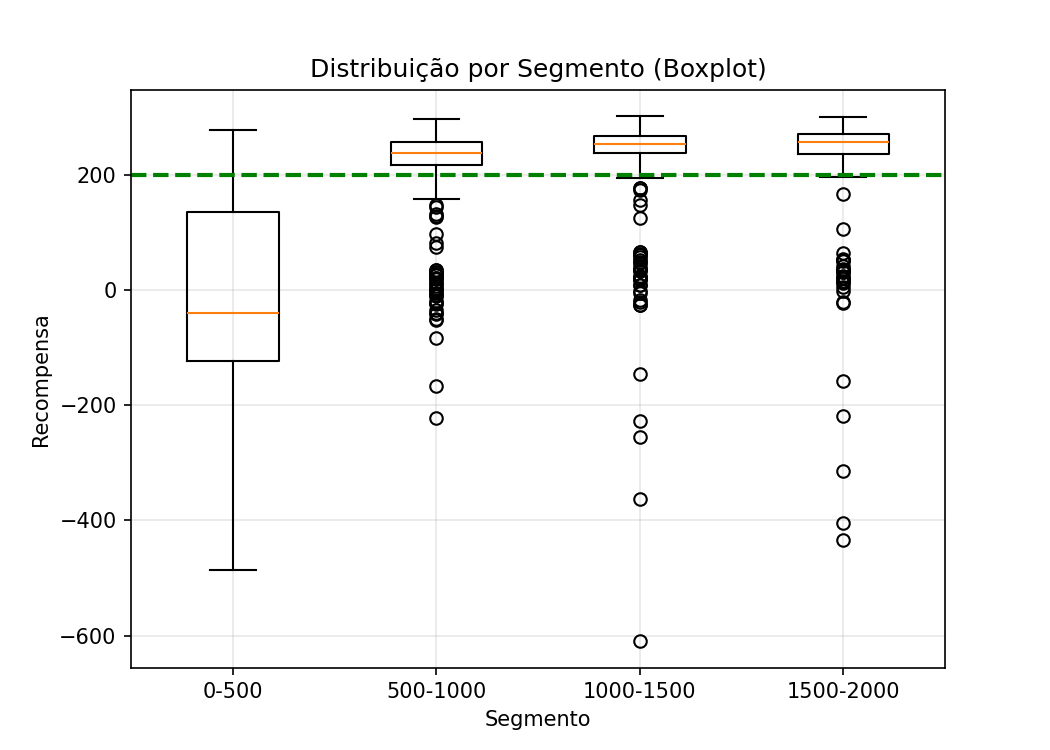

In [ ]:
plot_distribuicao_segmento(rewards, save_img)

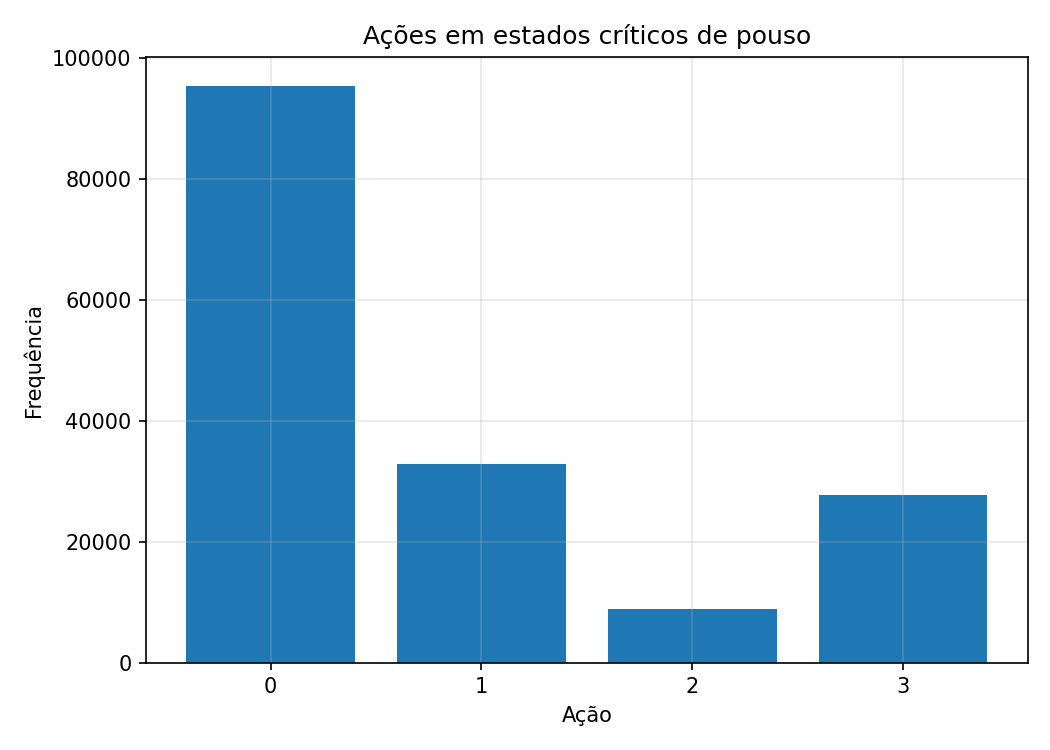

In [ ]:
plot_acoes_em_estado_critico(replay_buffer.buffer, save_img)

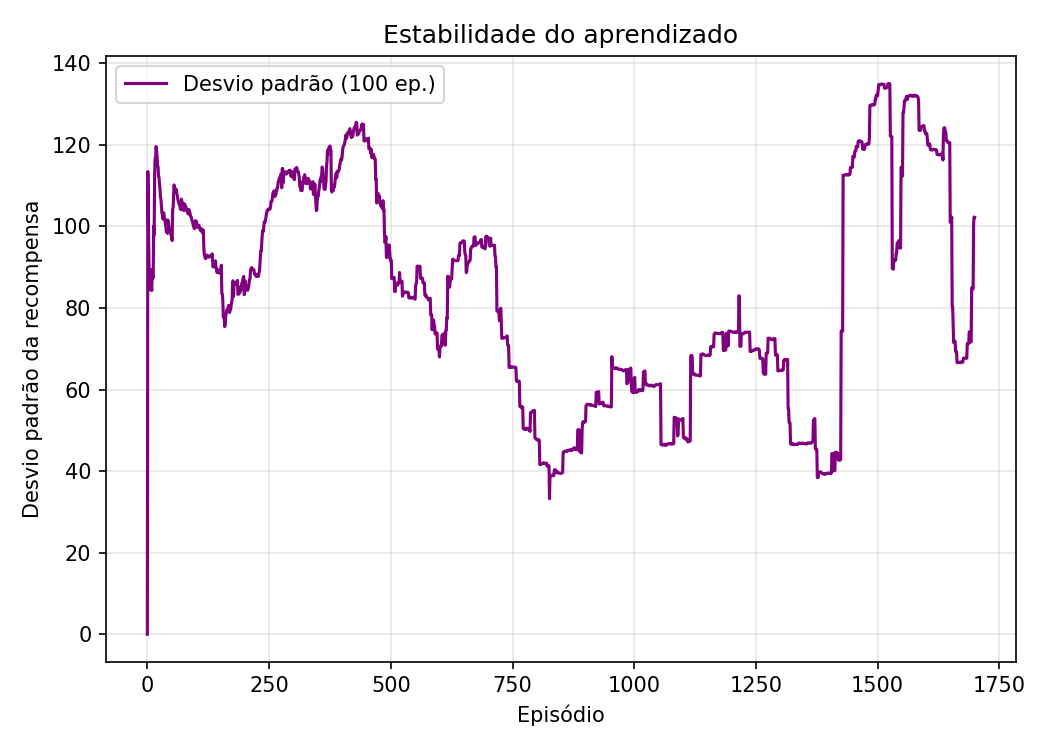

In [ ]:
plot_desvio_padrao_recompensa(rewards, save_img)

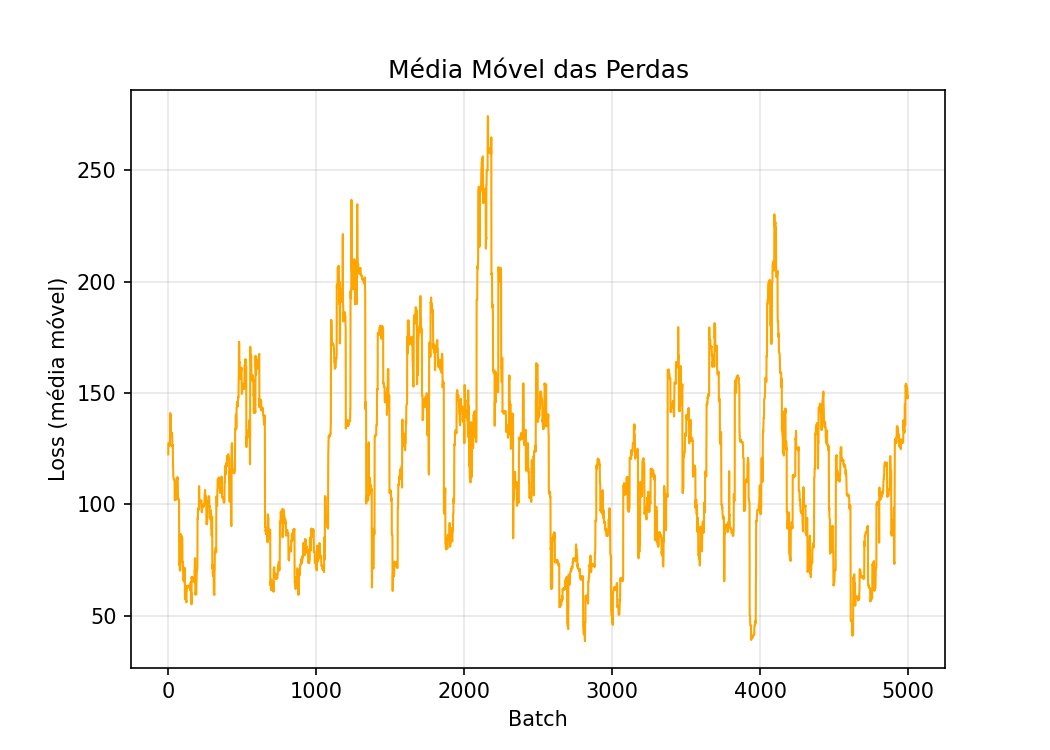

In [ ]:
plot_losses(agent.losses, save_img)

##Vídeos

In [ ]:
plot_video(env, layers, gamma, save_res, nome_agente)

Gravando vídeo do melhor agente...
Agente carregado de: resultados/fastkan_agente_6c665551aa.pt
Vídeo gerado: videos/video-b38d8b0814-episode-0.mp4
Recompensa total: 117.35


In [ ]:
plot_video(env, layers, gamma, save_res, nome_agente)

Gravando vídeo do melhor agente...
Agente carregado de: resultados/fastkan_agente_6c665551aa.pt
Vídeo gerado: videos/video-f1964733e0-episode-0.mp4
Recompensa total: 229.50


In [ ]:
plot_video(env, layers, gamma, save_res, nome_agente)

Gravando vídeo do melhor agente...
Agente carregado de: resultados/fastkan_agente_6c665551aa.pt
Vídeo gerado: videos/video-4a1029ab1a-episode-0.mp4
Recompensa total: 306.08


In [ ]:
plot_video(env, layers, gamma, save_res, nome_agente)

Gravando vídeo do melhor agente...
Agente carregado de: resultados/fastkan_agente_6c665551aa.pt
Vídeo gerado: videos/video-efaa7e3728-episode-0.mp4
Recompensa total: 264.98


#5 Execução (254)

In [ ]:
# Parâmetros de Execução Otimizados
seed = 254
set_seed(seed)
device = "cuda" if torch.cuda.is_available() else "cpu"
env_name = "LunarLander-v3"
num_episodes = 1700
capacity = 800000
batch_size = 16
n_step = 5
tau = 1.0
gamma = 0.99
lr = 1e-3
hidden_layers = [10, 10, 10]
warmup_episodes = 100
grid = 5 # número de divisões por dimensão FastKAN

# Cria o ambiente
env = gym.make(env_name)
env.reset(seed=seed)
env.action_space.seed(seed)

input_dim = env.observation_space.shape[0]
output_dim = env.action_space.n
layers = [input_dim] + hidden_layers + [output_dim]

# Configuração da rede KAN
modelo = RLModelFastKAN(
    width=layers,
    grid=grid,
    ).to(device)

# Inicializa otimizador, agente e buffer
optimizer = optim.Adam(modelo.parameters(), lr)
agent = Agente(modelo, optimizer, env, gamma, save_res)
replay_buffer = BufferMultiStep(capacity, n_step, gamma)

# Executa o treinamento
timer = Timer()

nome_agente, rewards, avg_rewards, best_reward, best_episode = run_experiment(
    env,
    agent,
    replay_buffer,
    num_episodes,
    batch_size,
    warmup_episodes,
    save_res,
    render=False
)
timer.stop()


(07:17:17) Iniciou execução...
Rodando na cuda:0
Ep    1/1700 [WARMUP] | R: -137.07 | Media10: -137.07 | Media100: -137.07 | eps: 0.995 | Buf:     85
Ep    2/1700 [WARMUP] | R: -133.72 | Media10: -135.40 | Media100: -135.40 | eps: 0.990 | Buf:    201
Ep    3/1700 [WARMUP] | R: -133.18 | Media10: -134.66 | Media100: -134.66 | eps: 0.985 | Buf:    306
Ep    4/1700 [WARMUP] | R: -106.05 | Media10: -127.51 | Media100: -127.51 | eps: 0.980 | Buf:    384
Ep    5/1700 [WARMUP] | R:  -92.68 | Media10: -120.54 | Media100: -120.54 | eps: 0.975 | Buf:    455
Ep    6/1700 [WARMUP] | R: -182.50 | Media10: -130.87 | Media100: -130.87 | eps: 0.970 | Buf:    540
Ep    7/1700 [WARMUP] | R: -100.94 | Media10: -126.59 | Media100: -126.59 | eps: 0.966 | Buf:    683
Ep    8/1700 [WARMUP] | R: -361.53 | Media10: -155.96 | Media100: -155.96 | eps: 0.961 | Buf:    800
Ep    9/1700 [WARMUP] | R: -168.42 | Media10: -157.34 | Media100: -157.34 | eps: 0.956 | Buf:    928
Ep   10/1700 [WARMUP] | R: -124.48 | Media

In [ ]:
caminho_arquivo = os.path.join(save_res, nome_agente)
print(f'{caminho_arquivo}')
# Verifica se o arquivo existe antes de tentar baixar
if os.path.exists(caminho_arquivo):
    files.download(caminho_arquivo)
else:
    print("Erro: O arquivo não foi encontrado na pasta /resultados.")

#6. Resultados (254)

## Desempenho

In [ ]:
plot_desempenho(rewards, best_reward, best_episode)

Desempenho:
 Melhor resultado: 303.36 (episódio 1606)
 Melhor média (100 ep): 263.57 (episódio 1600)
 Média últimos (100 ep): 252.11 ± 48.60
 Taxa de sucesso (>200): 95.0% (95/100)
Conclusão:
 SUCESSO! Agente RESOLVEU o ambiente!


In [ ]:
with torch.cuda.device(0):
  macs, params = get_model_complexity_info(
      modelo,
      (input_dim,),
      as_strings=True,
      print_per_layer_stat=True,
      verbose=True,
  )
print("FLOPs (MACs):", macs)
print("Parâmetros:", params)

RLModelFastKAN(
  430, 21.182% Params, 392.0 Mac, 100.000% MACs, 
  (kan_model): FastKAN(
    430, 21.182% Params, 392.0 Mac, 100.000% MACs, 
    (layers): ModuleList(
      (0): FastKANLayer(
        106, 5.222% Params, 98.0 Mac, 25.000% MACs, 
        (layernorm): LayerNorm(16, 0.788% Params, 8.0 Mac, 2.041% MACs, (8,), eps=1e-05, elementwise_affine=True)
        (rbf): RadialBasisFunction(0, 0.000% Params, 0.0 Mac, 0.000% MACs, )
        (spline_linear): SplineLinear(0, 0.000% Params, 0.0 Mac, 0.000% MACs, in_features=40, out_features=10, bias=False)
        (base_linear): Linear(90, 4.433% Params, 90.0 Mac, 22.959% MACs, in_features=8, out_features=10, bias=True)
      )
      (1-2): 2 x FastKANLayer(
        130, 6.404% Params, 120.0 Mac, 30.612% MACs, 
        (layernorm): LayerNorm(20, 0.985% Params, 10.0 Mac, 2.551% MACs, (10,), eps=1e-05, elementwise_affine=True)
        (rbf): RadialBasisFunction(0, 0.000% Params, 0.0 Mac, 0.000% MACs, )
        (spline_linear): SplineLinear(

## Arquitetura da Rede

In [ ]:
print(modelo)

RLModelFastKAN(
  (kan_model): FastKAN(
    (layers): ModuleList(
      (0): FastKANLayer(
        (layernorm): LayerNorm((8,), eps=1e-05, elementwise_affine=True)
        (rbf): RadialBasisFunction()
        (spline_linear): SplineLinear(in_features=40, out_features=10, bias=False)
        (base_linear): Linear(in_features=8, out_features=10, bias=True)
      )
      (1-2): 2 x FastKANLayer(
        (layernorm): LayerNorm((10,), eps=1e-05, elementwise_affine=True)
        (rbf): RadialBasisFunction()
        (spline_linear): SplineLinear(in_features=50, out_features=10, bias=False)
        (base_linear): Linear(in_features=10, out_features=10, bias=True)
      )
      (3): FastKANLayer(
        (layernorm): LayerNorm((10,), eps=1e-05, elementwise_affine=True)
        (rbf): RadialBasisFunction()
        (spline_linear): SplineLinear(in_features=50, out_features=4, bias=False)
        (base_linear): Linear(in_features=10, out_features=4, bias=True)
      )
    )
  )
)


In [ ]:
summary(modelo, input_size=(1, input_dim))

Layer (type:depth-idx)                             Output Shape              Param #
RLModelFastKAN                                     [1, 4]                    --
├─FastKAN: 1-1                                     [1, 4]                    --
│    └─ModuleList: 2-1                             --                        --
│    │    └─FastKANLayer: 3-1                      [1, 10]                   511
│    │    └─FastKANLayer: 3-2                      [1, 10]                   635
│    │    └─FastKANLayer: 3-3                      [1, 10]                   635
│    │    └─FastKANLayer: 3-4                      [1, 4]                    269
Total params: 2,050
Trainable params: 2,030
Non-trainable params: 20
Total mult-adds (Units.MEGABYTES): 0.00
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.01
Estimated Total Size (MB): 0.01

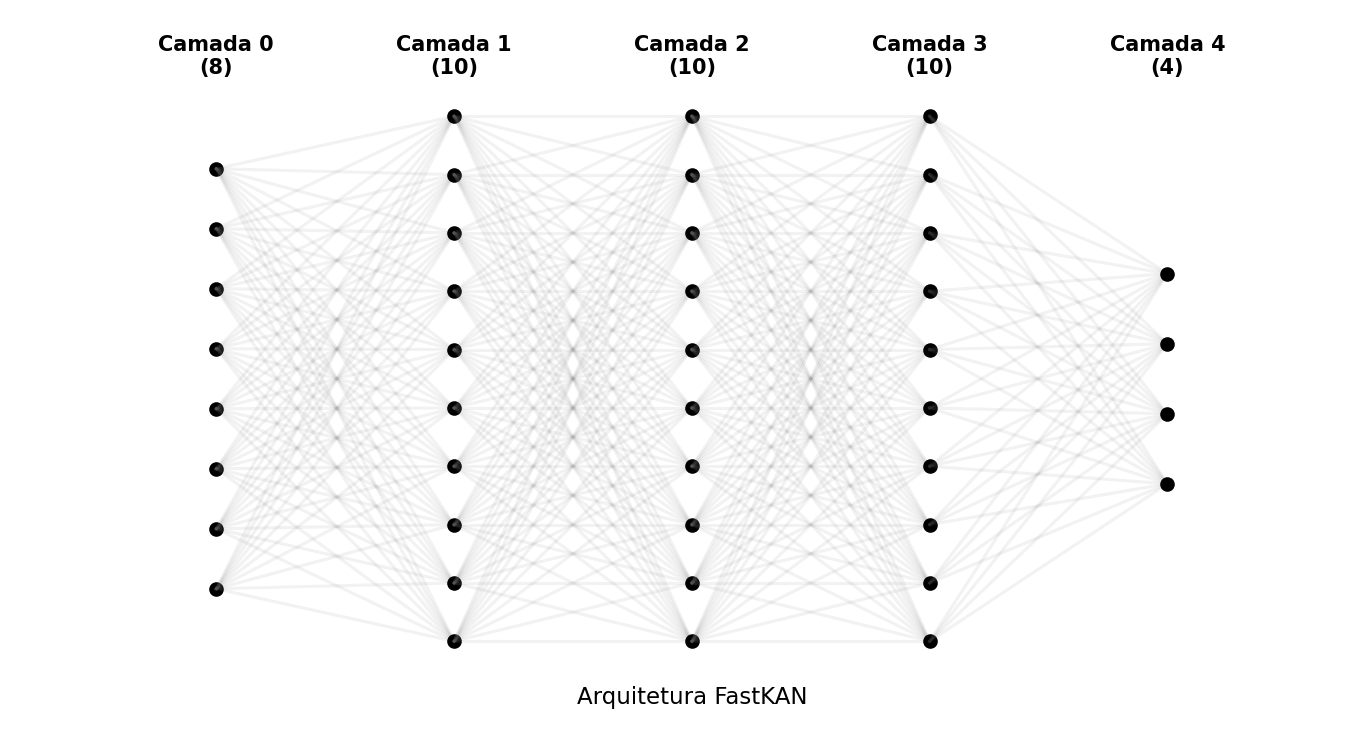

In [ ]:
plot_fastkan_arquitetura(input_dim, hidden_layers, output_dim, save_img)

## Gráficos

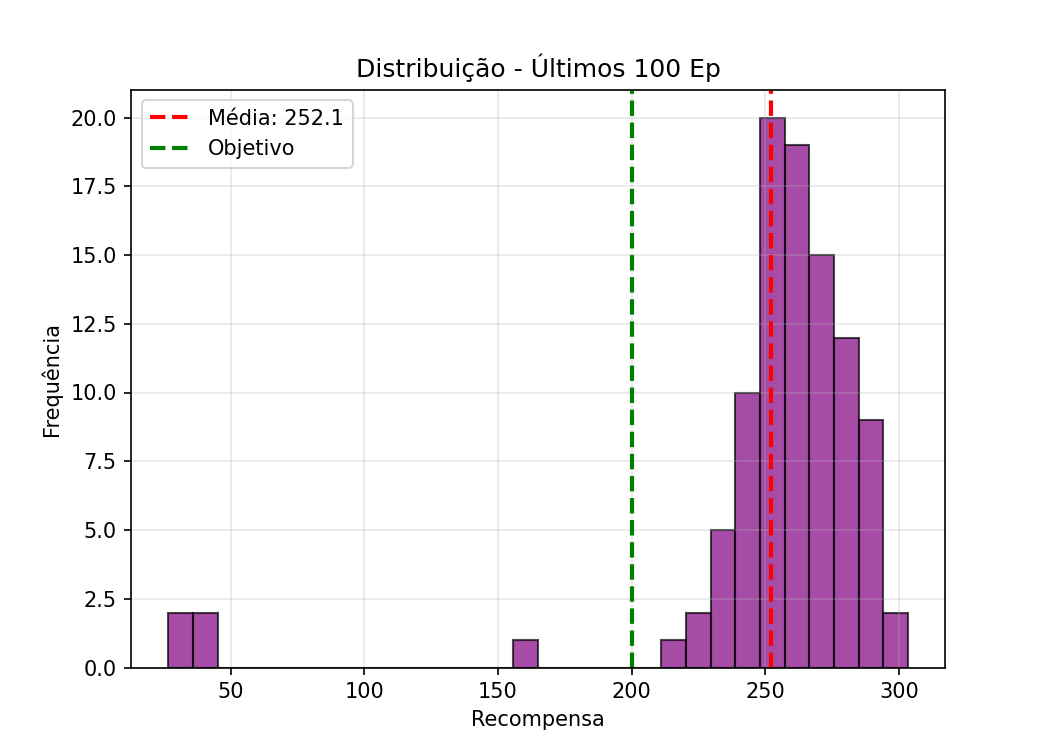

In [ ]:
plot_distribuicao_recompensa(rewards, save_img)

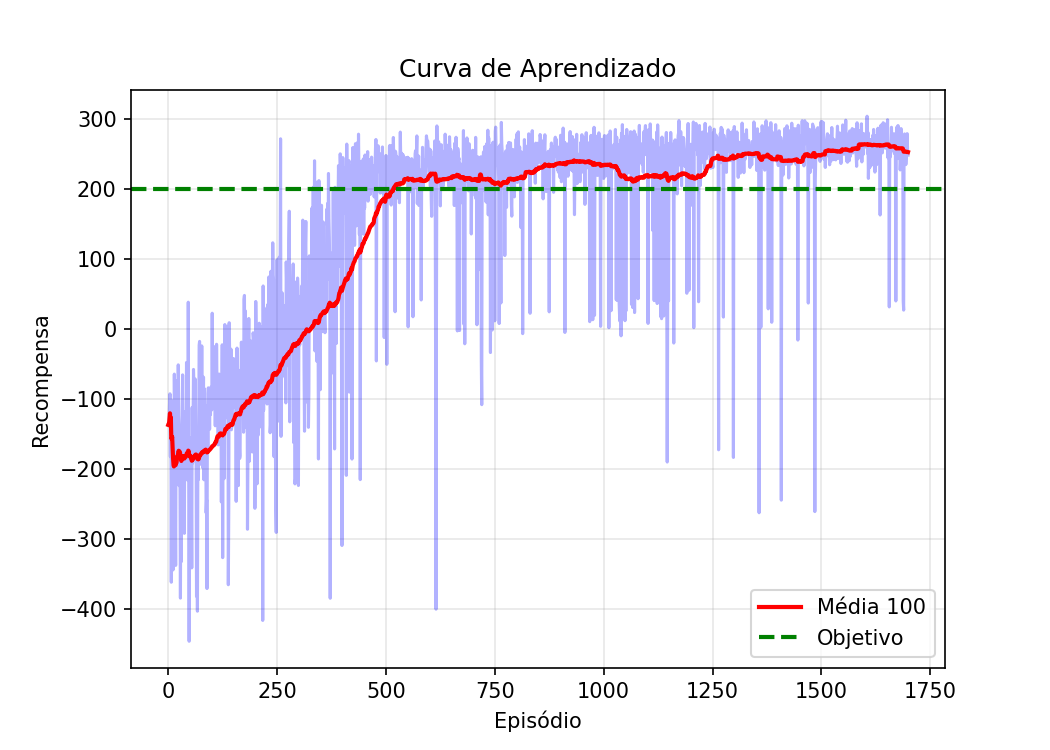

In [ ]:
plot_curva_aprendizado(rewards, save_img)

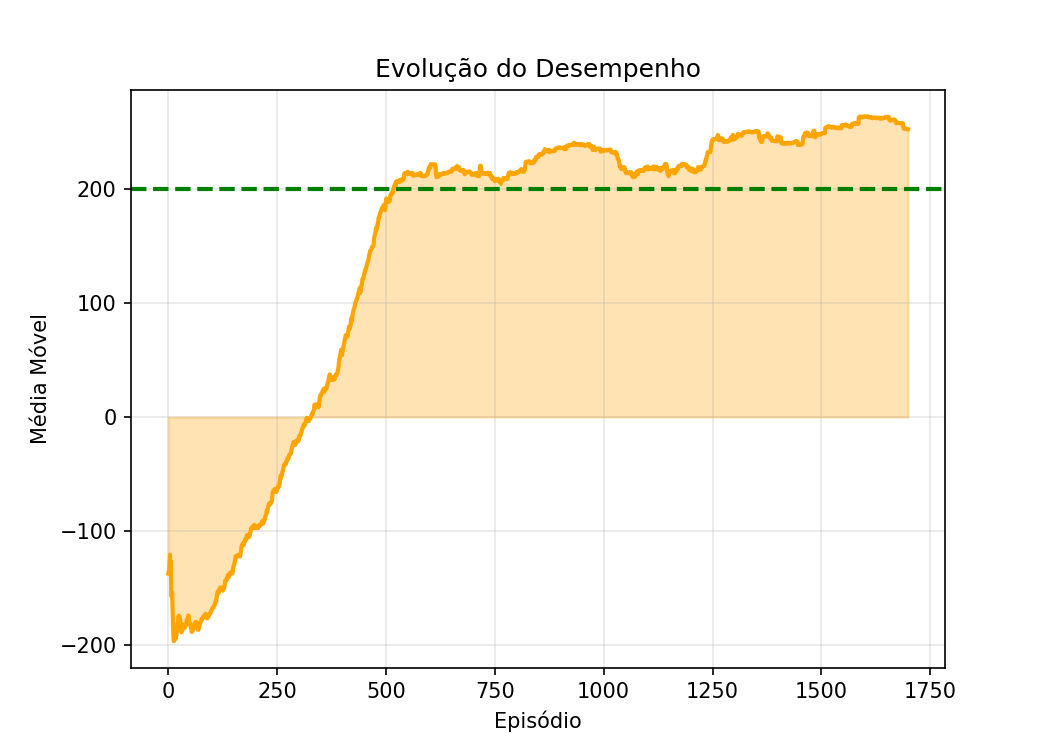

In [ ]:
plot_evolucao_desempenho(rewards, save_img)

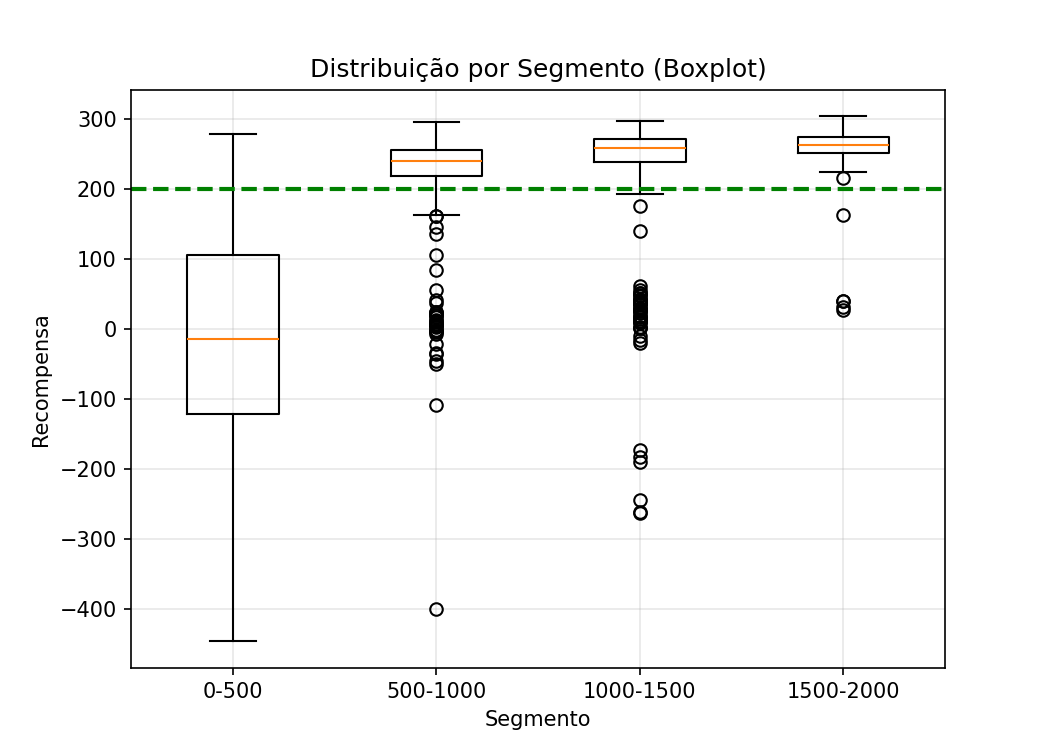

In [ ]:
plot_distribuicao_segmento(rewards, save_img)

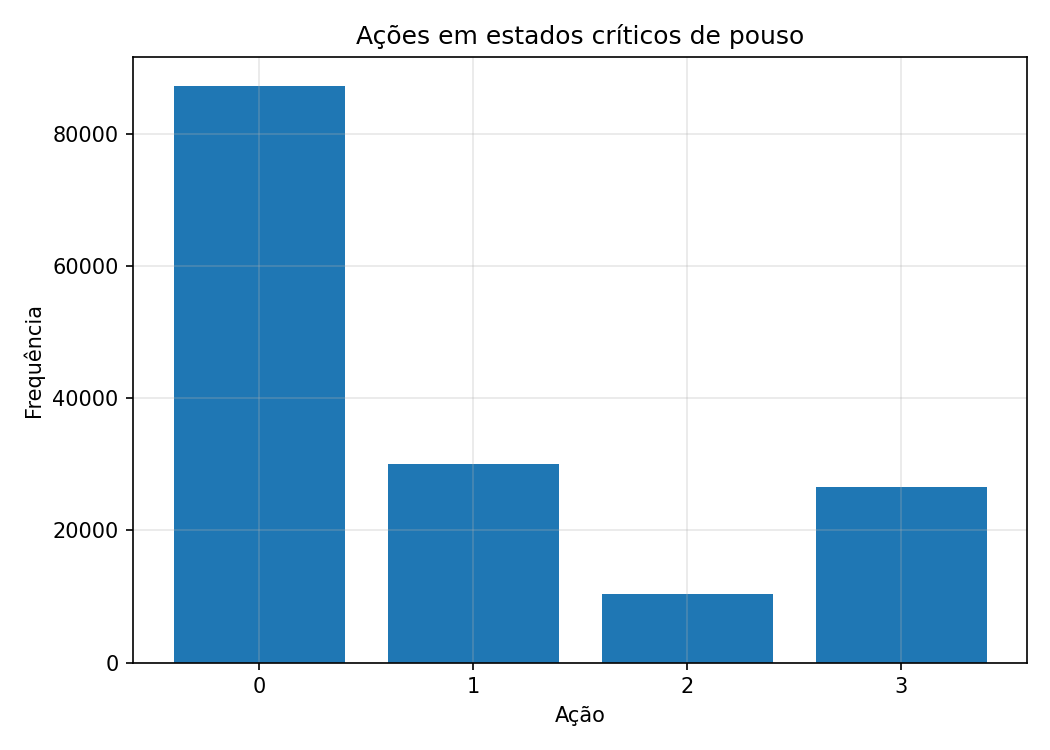

In [ ]:
plot_acoes_em_estado_critico(replay_buffer.buffer, save_img)

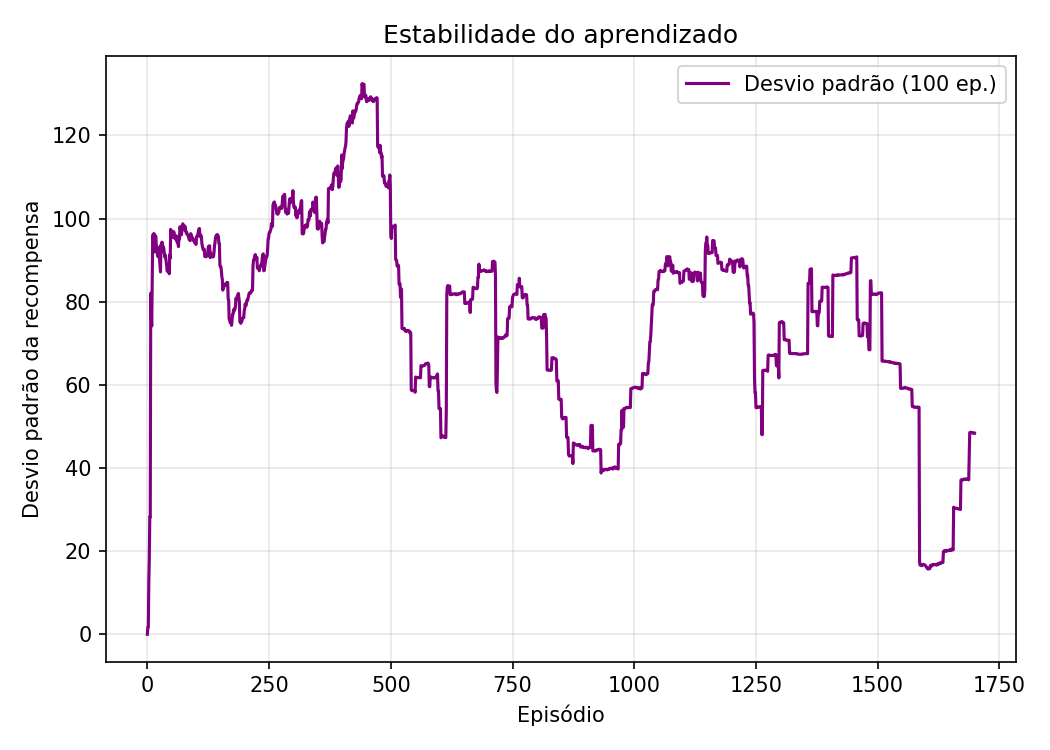

In [ ]:
plot_desvio_padrao_recompensa(rewards, save_img)

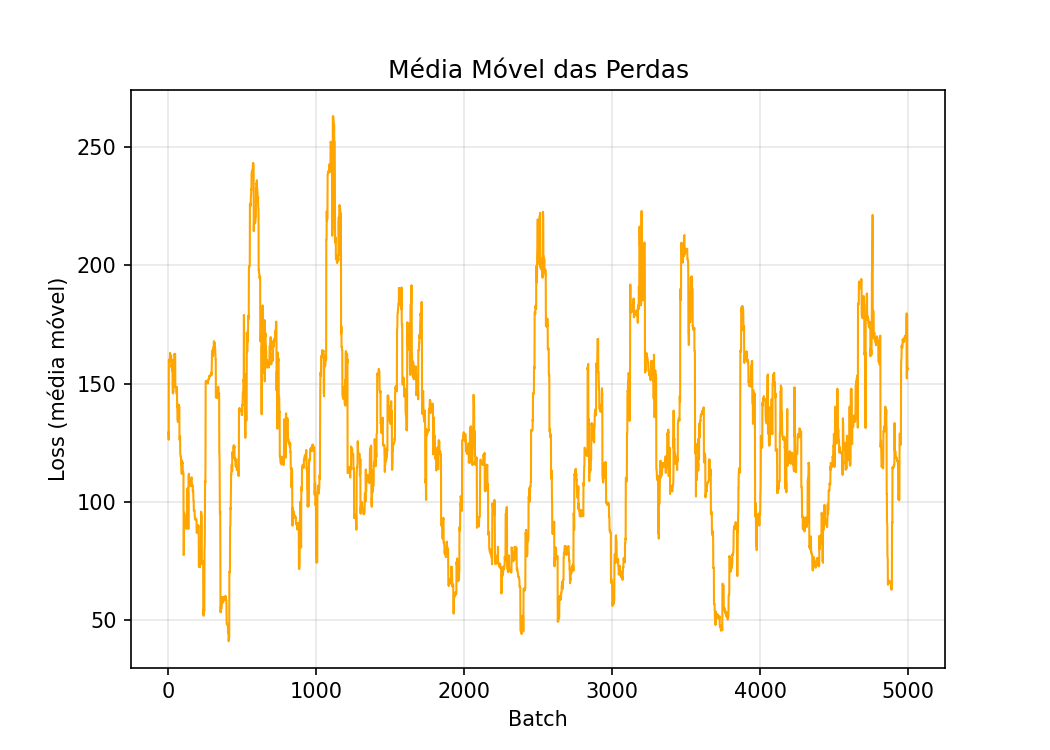

In [ ]:
plot_losses(agent.losses, save_img)

##Vídeos

In [ ]:
plot_video(env, layers, gamma, save_res, nome_agente)

Gravando vídeo do melhor agente...
Agente carregado de: resultados/fastkan_agente_7d651a9825.pt
Vídeo gerado: videos/video-b9bfd2131d-episode-0.mp4
Recompensa total: 238.06


In [ ]:
plot_video(env, layers, gamma, save_res, nome_agente)

Gravando vídeo do melhor agente...
Agente carregado de: resultados/fastkan_agente_7d651a9825.pt
Vídeo gerado: videos/video-997fcb70e5-episode-0.mp4
Recompensa total: 279.98


In [ ]:
plot_video(env, layers, gamma, save_res, nome_agente)

Gravando vídeo do melhor agente...
Agente carregado de: resultados/fastkan_agente_7d651a9825.pt
Vídeo gerado: videos/video-d7696eadc5-episode-0.mp4
Recompensa total: 221.51


In [ ]:
plot_video(env, layers, gamma, save_res, nome_agente)

Gravando vídeo do melhor agente...
Agente carregado de: resultados/fastkan_agente_7d651a9825.pt
Vídeo gerado: videos/video-2b202ad893-episode-0.mp4
Recompensa total: 283.48


In [ ]:
plot_video(env, layers, gamma, save_res, nome_agente)

Gravando vídeo do melhor agente...
Agente carregado de: resultados/fastkan_agente_7d651a9825.pt
Vídeo gerado: videos/video-2c614f9e84-episode-0.mp4
Recompensa total: 223.91


# 5. Execução (2026)

In [ ]:
# Parâmetros de Execução Otimizados
seed = 2026
set_seed(seed)
device = "cuda" if torch.cuda.is_available() else "cpu"
env_name = "LunarLander-v3"
num_episodes = 1700
capacity = 800000
batch_size = 16
n_step = 5
tau = 1.0
gamma = 0.99
lr = 1e-3
hidden_layers = [10, 10, 10]
warmup_episodes = 100
grid = 5 # número de divisões por dimensão FastKAN

# Cria o ambiente
env = gym.make(env_name)
env.reset(seed=seed)
env.action_space.seed(seed)

input_dim = env.observation_space.shape[0]
output_dim = env.action_space.n
layers = [input_dim] + hidden_layers + [output_dim]

# Configuração da rede KAN
modelo = RLModelFastKAN(
    width=layers,
    grid=grid,
    ).to(device)

# Inicializa otimizador, agente e buffer
optimizer = optim.Adam(modelo.parameters(), lr)
agent = Agente(modelo, optimizer, env, gamma, save_res)
replay_buffer = BufferMultiStep(capacity, n_step, gamma)

# Executa o treinamento
timer = Timer()

nome_agente, rewards, avg_rewards, best_reward, best_episode = run_experiment(
    env,
    agent,
    replay_buffer,
    num_episodes,
    batch_size,
    warmup_episodes,
    save_res,
    render=False
)
timer.stop()


(17:42:53) Iniciou execução...
Rodando na cuda:0
Ep    1/1700 [WARMUP] | R:  -99.67 | Media10:  -99.67 | Media100:  -99.67 | eps: 0.995 | Buf:     77
Ep    2/1700 [WARMUP] | R: -145.61 | Media10: -122.64 | Media100: -122.64 | eps: 0.990 | Buf:    144
Ep    3/1700 [WARMUP] | R:  -42.27 | Media10:  -95.85 | Media100:  -95.85 | eps: 0.985 | Buf:    253
Ep    4/1700 [WARMUP] | R:  -86.66 | Media10:  -93.55 | Media100:  -93.55 | eps: 0.980 | Buf:    383
Ep    5/1700 [WARMUP] | R: -105.48 | Media10:  -95.94 | Media100:  -95.94 | eps: 0.975 | Buf:    445
Ep    6/1700 [WARMUP] | R: -273.16 | Media10: -125.48 | Media100: -125.48 | eps: 0.970 | Buf:    510
Ep    7/1700 [WARMUP] | R:  -84.76 | Media10: -119.66 | Media100: -119.66 | eps: 0.966 | Buf:    646
Ep    8/1700 [WARMUP] | R: -163.63 | Media10: -125.15 | Media100: -125.15 | eps: 0.961 | Buf:    709
Ep    9/1700 [WARMUP] | R: -196.74 | Media10: -133.11 | Media100: -133.11 | eps: 0.956 | Buf:    834
Ep   10/1700 [WARMUP] | R: -146.24 | Media

In [ ]:
caminho_arquivo = os.path.join(save_res, nome_agente)
print(f'{caminho_arquivo}')
# Verifica se o arquivo existe antes de tentar baixar
if os.path.exists(caminho_arquivo):
    files.download(caminho_arquivo)
else:
    print("Erro: O arquivo não foi encontrado na pasta /resultados.")

#6. Resultados (2026)

In [ ]:
print('seed', seed)
print('device', device)
print('env_name', env_name)
print('num_episodes', num_episodes)
print('capacity', capacity)
print('batch_size', batch_size)
print('n_step', n_step)
print('tau', tau)
print('gamma', gamma)
print('lr', lr)
print('hidden_layers', hidden_layers)
print('warmup_episodes', warmup_episodes)
print('grid', grid)

seed 2026
device cuda
env_name LunarLander-v3
num_episodes 1700
capacity 800000
batch_size 16
n_step 5
tau 1.0
gamma 0.99
lr 0.001
hidden_layers [10, 10, 10]
warmup_episodes 100
grid 5


## Desempenho

In [ ]:
plot_desempenho(rewards, best_reward, best_episode)

Desempenho:
 Melhor resultado: 309.73 (episódio 1377)
 Melhor média (100 ep): 257.62 (episódio 1231)
 Média últimos (100 ep): 240.77 ± 68.69
 Taxa de sucesso (>200): 88.0% (88/100)
Conclusão:
 SUCESSO! Agente RESOLVEU o ambiente!


In [ ]:
with torch.cuda.device(0):
  macs, params = get_model_complexity_info(
      modelo,
      (input_dim,),
      as_strings=True,
      print_per_layer_stat=True,
      verbose=True,
  )
print("FLOPs (MACs):", macs)
print("Parâmetros:", params)

RLModelFastKAN(
  430, 21.182% Params, 392.0 Mac, 100.000% MACs, 
  (kan_model): FastKAN(
    430, 21.182% Params, 392.0 Mac, 100.000% MACs, 
    (layers): ModuleList(
      (0): FastKANLayer(
        106, 5.222% Params, 98.0 Mac, 25.000% MACs, 
        (layernorm): LayerNorm(16, 0.788% Params, 8.0 Mac, 2.041% MACs, (8,), eps=1e-05, elementwise_affine=True)
        (rbf): RadialBasisFunction(0, 0.000% Params, 0.0 Mac, 0.000% MACs, )
        (spline_linear): SplineLinear(0, 0.000% Params, 0.0 Mac, 0.000% MACs, in_features=40, out_features=10, bias=False)
        (base_linear): Linear(90, 4.433% Params, 90.0 Mac, 22.959% MACs, in_features=8, out_features=10, bias=True)
      )
      (1-2): 2 x FastKANLayer(
        130, 6.404% Params, 120.0 Mac, 30.612% MACs, 
        (layernorm): LayerNorm(20, 0.985% Params, 10.0 Mac, 2.551% MACs, (10,), eps=1e-05, elementwise_affine=True)
        (rbf): RadialBasisFunction(0, 0.000% Params, 0.0 Mac, 0.000% MACs, )
        (spline_linear): SplineLinear(

## Arquitetura da Rede

In [ ]:
print(modelo)

RLModelFastKAN(
  (kan_model): FastKAN(
    (layers): ModuleList(
      (0): FastKANLayer(
        (layernorm): LayerNorm((8,), eps=1e-05, elementwise_affine=True)
        (rbf): RadialBasisFunction()
        (spline_linear): SplineLinear(in_features=40, out_features=10, bias=False)
        (base_linear): Linear(in_features=8, out_features=10, bias=True)
      )
      (1-2): 2 x FastKANLayer(
        (layernorm): LayerNorm((10,), eps=1e-05, elementwise_affine=True)
        (rbf): RadialBasisFunction()
        (spline_linear): SplineLinear(in_features=50, out_features=10, bias=False)
        (base_linear): Linear(in_features=10, out_features=10, bias=True)
      )
      (3): FastKANLayer(
        (layernorm): LayerNorm((10,), eps=1e-05, elementwise_affine=True)
        (rbf): RadialBasisFunction()
        (spline_linear): SplineLinear(in_features=50, out_features=4, bias=False)
        (base_linear): Linear(in_features=10, out_features=4, bias=True)
      )
    )
  )
)


In [ ]:
summary(modelo, input_size=(1, input_dim))

Layer (type:depth-idx)                             Output Shape              Param #
RLModelFastKAN                                     [1, 4]                    --
├─FastKAN: 1-1                                     [1, 4]                    --
│    └─ModuleList: 2-1                             --                        --
│    │    └─FastKANLayer: 3-1                      [1, 10]                   511
│    │    └─FastKANLayer: 3-2                      [1, 10]                   635
│    │    └─FastKANLayer: 3-3                      [1, 10]                   635
│    │    └─FastKANLayer: 3-4                      [1, 4]                    269
Total params: 2,050
Trainable params: 2,030
Non-trainable params: 20
Total mult-adds (Units.MEGABYTES): 0.00
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.01
Estimated Total Size (MB): 0.01

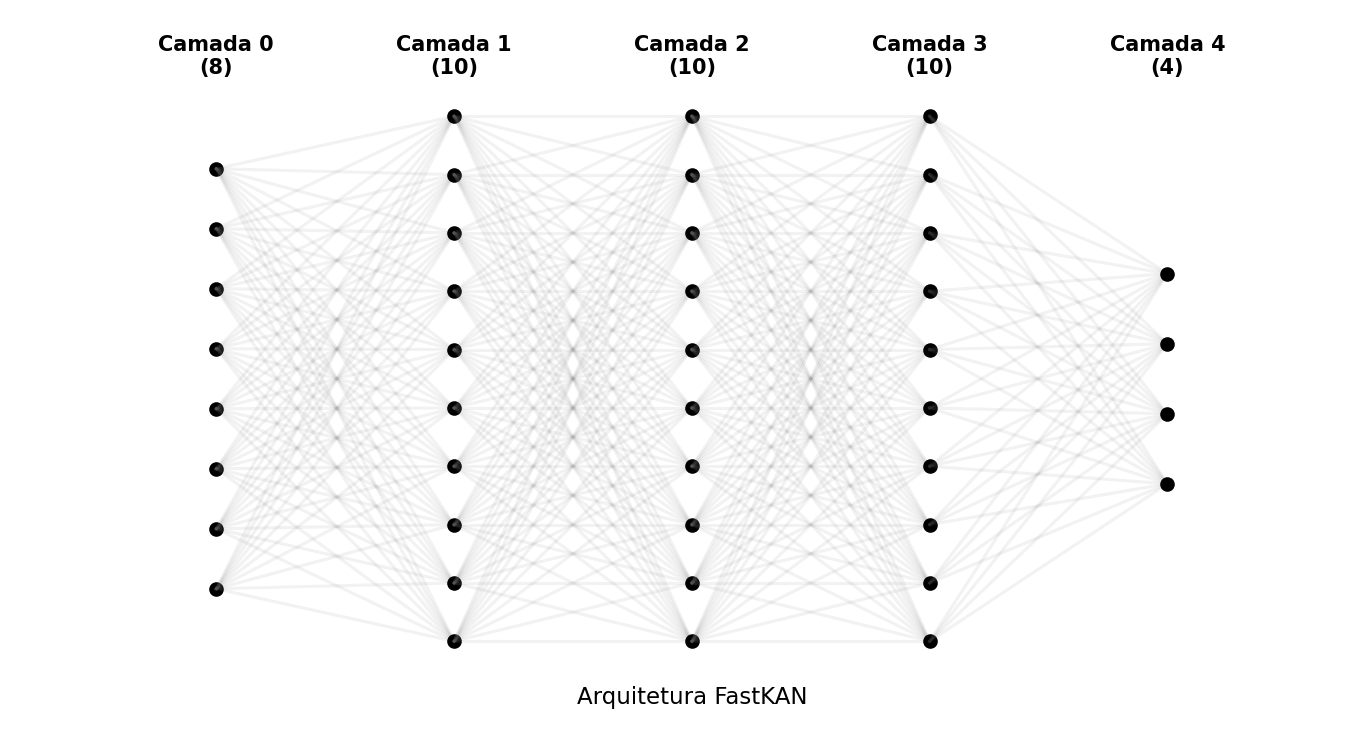

In [ ]:
plot_fastkan_arquitetura(input_dim, hidden_layers, output_dim, save_img)

## Gráficos

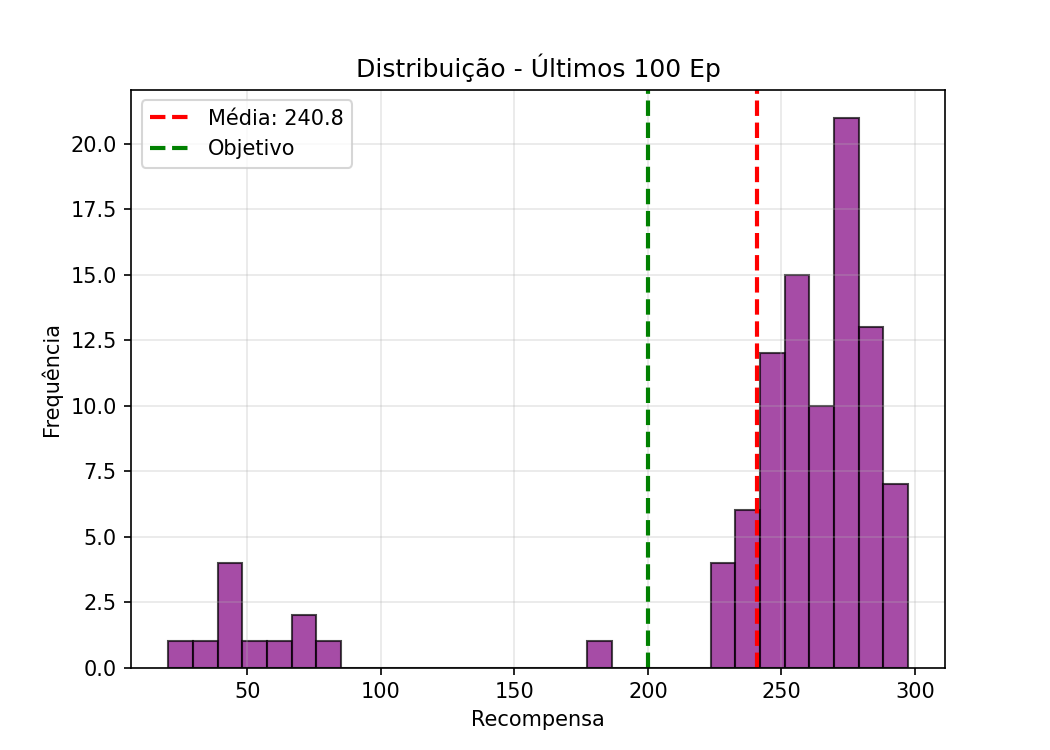

In [ ]:
plot_distribuicao_recompensa(rewards, save_img)

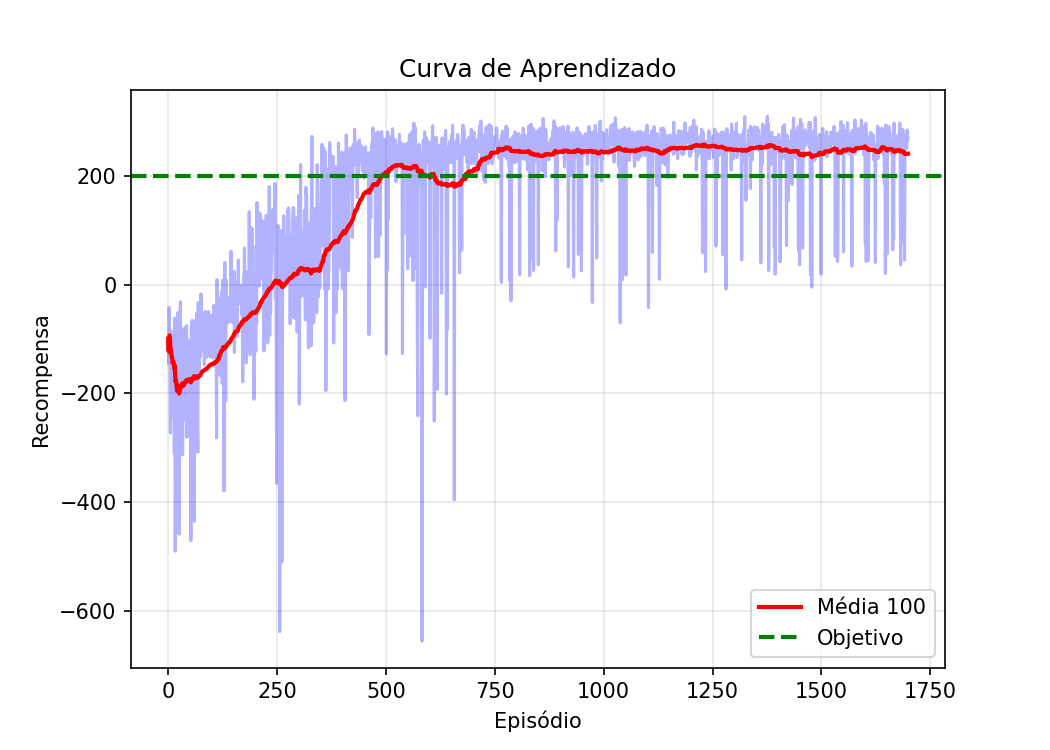

In [ ]:
plot_curva_aprendizado(rewards, save_img)

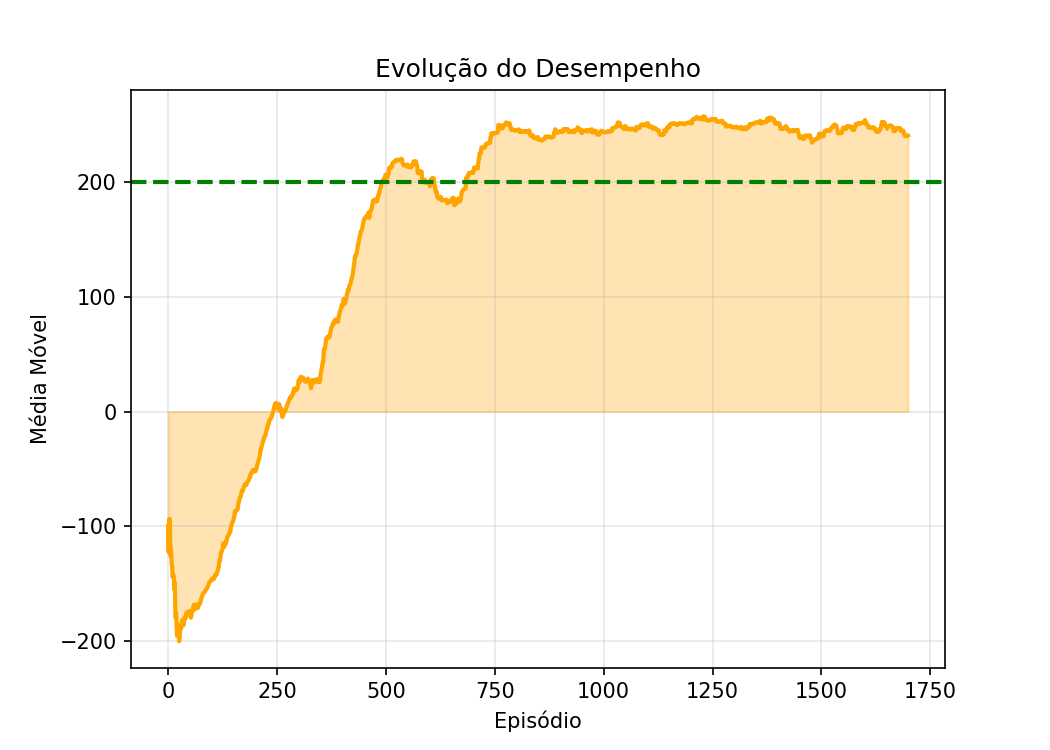

In [ ]:
plot_evolucao_desempenho(rewards, save_img)

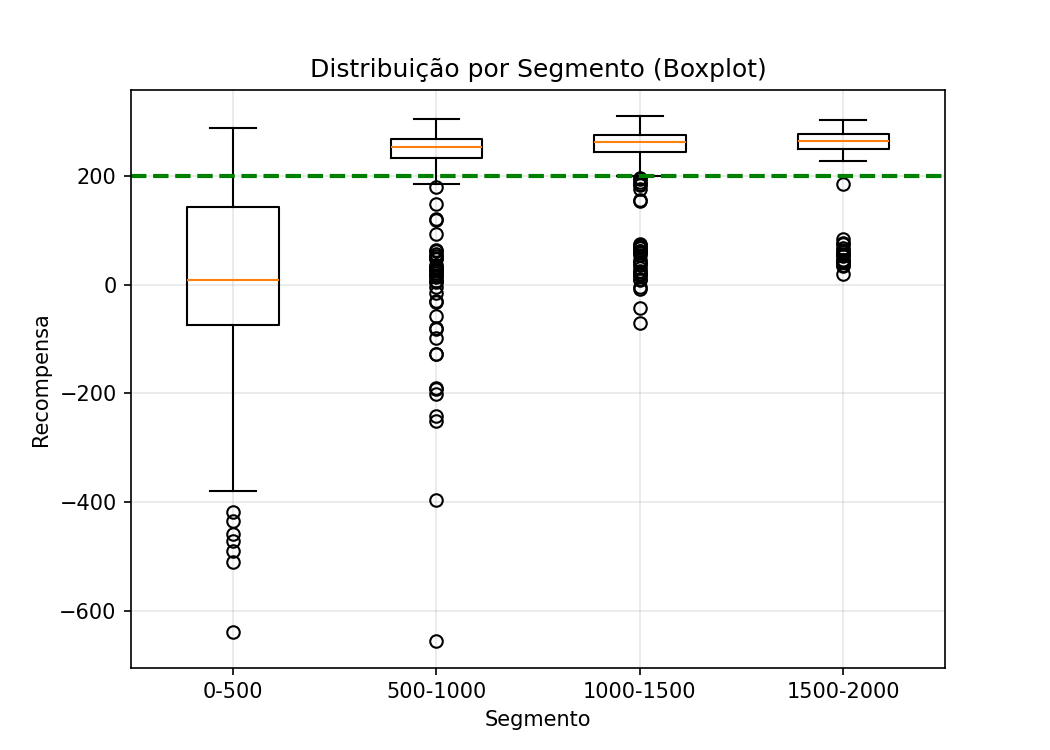

In [ ]:
plot_distribuicao_segmento(rewards, save_img)

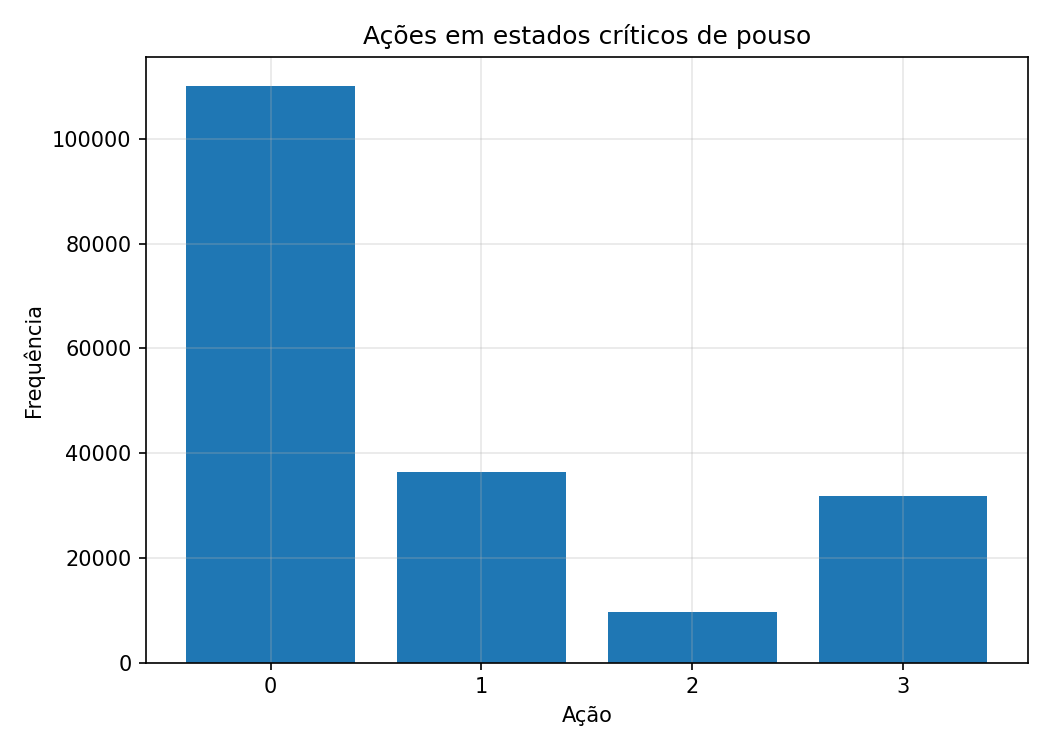

In [ ]:
plot_acoes_em_estado_critico(replay_buffer.buffer, save_img)

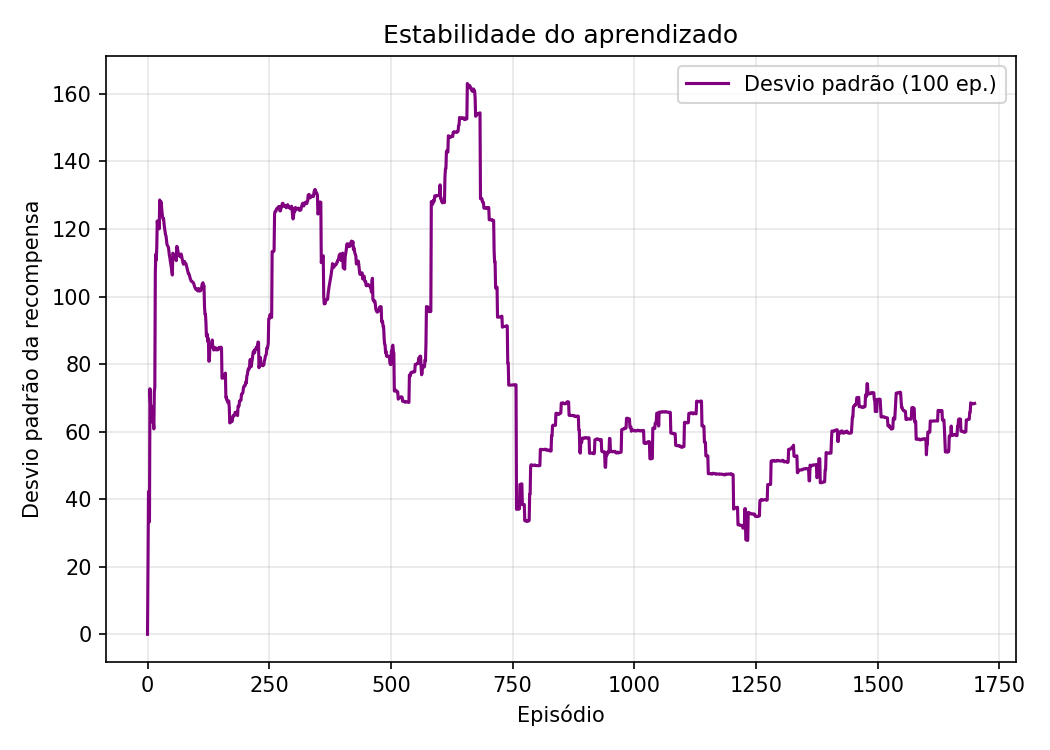

In [ ]:
plot_desvio_padrao_recompensa(rewards, save_img)

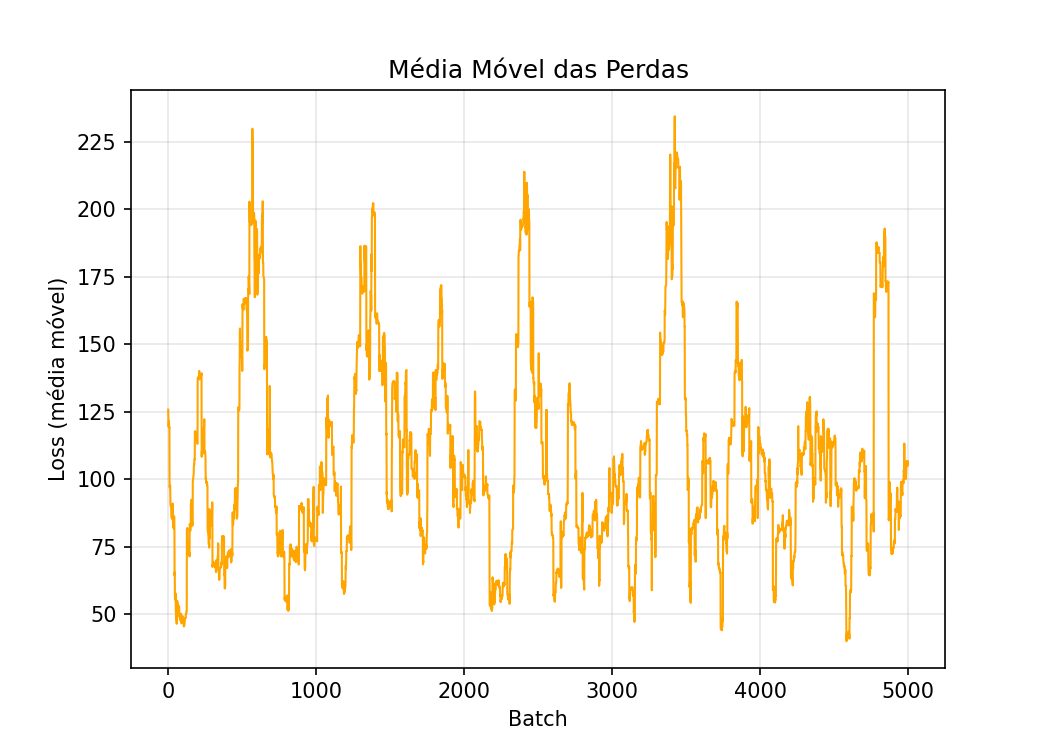

In [ ]:
plot_losses(agent.losses, save_img)

##Vídeos

In [ ]:
plot_video(env, layers, gamma, save_res, nome_agente)

Gravando vídeo do melhor agente...
Agente carregado de: resultados/fastkan_agente_62ace503f2.pt
Vídeo gerado: videos/video-70040cca3a-episode-0.mp4
Recompensa total: 244.80


In [ ]:
plot_video(env, layers, gamma, save_res, nome_agente)

Gravando vídeo do melhor agente...
Agente carregado de: resultados/fastkan_agente_62ace503f2.pt
Vídeo gerado: videos/video-a07280ac28-episode-0.mp4
Recompensa total: 267.59


In [ ]:
plot_video(env, layers, gamma, save_res, nome_agente)

Gravando vídeo do melhor agente...
Agente carregado de: resultados/fastkan_agente_62ace503f2.pt
Vídeo gerado: videos/video-5fbfbb32bd-episode-0.mp4
Recompensa total: 249.37


In [ ]:
plot_video(env, layers, gamma, save_res, nome_agente)

Gravando vídeo do melhor agente...
Agente carregado de: resultados/fastkan_agente_62ace503f2.pt
Vídeo gerado: videos/video-14680ad536-episode-0.mp4
Recompensa total: 172.96


In [ ]:
plot_video(env, layers, gamma, save_res, nome_agente)

Gravando vídeo do melhor agente...
Agente carregado de: resultados/fastkan_agente_62ace503f2.pt
Vídeo gerado: videos/video-6f7a70f0b1-episode-0.mp4
Recompensa total: 293.01


In [ ]:
plot_video(env, layers, gamma, save_res, nome_agente)

Gravando vídeo do melhor agente...
Agente carregado de: resultados/fastkan_agente_62ace503f2.pt
Vídeo gerado: videos/video-76b1fb49a6-episode-0.mp4
Recompensa total: 10.77
